In [139]:
# Import packages

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import  sklearn.decomposition as PCA
import sklearn.preprocessing as StandardScaler
import scipy.stats as stats

In [140]:
# Definition du chemin d'acces
import os
os.chdir('C:/Users/brech/Downloads')

#### 1.1 Import des données

In [142]:
# Importation du dataframe
df = pd.read_excel("USDA_National_Nutrient_DataBase.xlsx")
# Afficher les premiere lignes du tableau
df.head()

,NDB_No,Shrt_Desc,Water_(g),Energ_Kcal,Protein_(g),Lipid_Tot_(g),Ash_(g),Carbohydrt_(g),Fiber_TD_(g),Sugar_Tot_(g),...,Vit_K_(µg),FA_Sat_(g),FA_Mono_(g),FA_Poly_(g),Cholestrl_(mg),GmWt_1,GmWt_Desc1,GmWt_2,GmWt_Desc2,Refuse_Pct
0,1001,"BUTTER,WITH SALT",15.87,717,0.85,81.11,2.11,0.06,0.0,0.06,...,7.0,51.368,21.021,3.043,215.0,5.00,"1 pat, (1"" sq, 1/3"" high)",14.2,1 tbsp,0.0
1,1002,"BUTTER,WHIPPED,W/ SALT",16.72,718,0.49,78.30,1.62,2.87,0.0,0.06,...,4.6,45.390,19.874,3.331,225.0,3.80,"1 pat, (1"" sq, 1/3"" high)",9.4,1 tbsp,0.0
2,1003,"BUTTER OIL,ANHYDROUS",0.24,876,0.28,99.48,0.00,0.00,0.0,0.00,...,8.6,61.924,28.732,3.694,256.0,12.80,1 tbsp,205.0,1 cup,0.0
3,1004,"CHEESE,BLUE",42.41,353,21.40,28.74,5.11,2.34,0.0,0.50,...,2.4,18.669,7.778,0.800,75.0,28.35,1 oz,17.0,1 cubic inch,0.0
4,1005,"CHEESE,BRICK",41.11,371,23.24,29.68,3.18,2.79,0.0,0.51,...,2.5,18.764,8.598,0.784,94.0,132.00,"1 cup, diced",113.0,"1 cup, shredded",0.0


In [143]:
# Changement d'index
# pour faire de la premiere colonne, la colonne des observations
df = df.set_index('NDB_No')

In [144]:
# Analyse de la dimension de la base de données
df.shape

(8790, 52)

In [145]:
# Analyse de l'ensemble des variables de la base de données
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 1001 to 93600
Data columns (total 52 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Shrt_Desc          8790 non-null   object 
 1   Water_(g)          8789 non-null   float64
 2   Energ_Kcal         8790 non-null   int64  
 3   Protein_(g)        8790 non-null   float64
 4   Lipid_Tot_(g)      8790 non-null   float64
 5   Ash_(g)            8465 non-null   float64
 6   Carbohydrt_(g)     8790 non-null   float64
 7   Fiber_TD_(g)       8196 non-null   float64
 8   Sugar_Tot_(g)      6958 non-null   float64
 9   Calcium_(mg)       8442 non-null   float64
 10  Iron_(mg)          8646 non-null   float64
 11  Magnesium_(mg)     8051 non-null   float64
 12  Phosphorus_(mg)    8211 non-null   float64
 13  Potassium_(mg)     8364 non-null   float64
 14  Sodium_(mg)        8707 non-null   float64
 15  Zinc_(mg)          8084 non-null   float64
 16  Copper_mg)         7533 n

In [146]:
# Analyse du type de variable dans la base de données
df.dtypes

Shrt_Desc             object
Water_(g)            float64
Energ_Kcal             int64
Protein_(g)          float64
Lipid_Tot_(g)        float64
Ash_(g)              float64
Carbohydrt_(g)       float64
Fiber_TD_(g)         float64
Sugar_Tot_(g)        float64
Calcium_(mg)         float64
Iron_(mg)            float64
Magnesium_(mg)       float64
Phosphorus_(mg)      float64
Potassium_(mg)       float64
Sodium_(mg)          float64
Zinc_(mg)            float64
Copper_mg)           float64
Manganese_(mg)       float64
Selenium_(µg)        float64
Vit_C_(mg)           float64
Thiamin_(mg)         float64
Riboflavin_(mg)      float64
Niacin_(mg)          float64
Panto_Acid_mg)       float64
Vit_B6_(mg)          float64
Folate_Tot_(µg)      float64
Folic_Acid_(µg)      float64
Food_Folate_(µg)     float64
Folate_DFE_(µg)      float64
Choline_Tot_ (mg)    float64
Vit_B12_(µg)         float64
Vit_A_IU             float64
Vit_A_RAE            float64
Retinol_(µg)         float64
Alpha_Carot_(µ

In [147]:
# Verifier les doublons dans toutes les colonnes
duplicates = df[df.duplicated()]

# Afficher les doublons
print("Doublons trouvés:")
print(duplicates)

Doublons trouvés:
Empty DataFrame
Columns: [Shrt_Desc, Water_(g), Energ_Kcal, Protein_(g), Lipid_Tot_(g), Ash_(g), Carbohydrt_(g), Fiber_TD_(g), Sugar_Tot_(g), Calcium_(mg), Iron_(mg), Magnesium_(mg), Phosphorus_(mg), Potassium_(mg), Sodium_(mg), Zinc_(mg), Copper_mg), Manganese_(mg), Selenium_(µg), Vit_C_(mg), Thiamin_(mg), Riboflavin_(mg), Niacin_(mg), Panto_Acid_mg), Vit_B6_(mg), Folate_Tot_(µg), Folic_Acid_(µg), Food_Folate_(µg), Folate_DFE_(µg), Choline_Tot_ (mg), Vit_B12_(µg), Vit_A_IU, Vit_A_RAE, Retinol_(µg), Alpha_Carot_(µg), Beta_Carot_(µg), Beta_Crypt_(µg), Lycopene_(µg), Lut+Zea_ (µg), Vit_E_(mg), Vit_D_µg, Vit_D_IU, Vit_K_(µg), FA_Sat_(g), FA_Mono_(g), FA_Poly_(g), Cholestrl_(mg), GmWt_1, GmWt_Desc1, GmWt_2, GmWt_Desc2, Refuse_Pct]
Index: []

[0 rows x 52 columns]


#### 1.2 Analyse  des données manquantes

<Axes: >

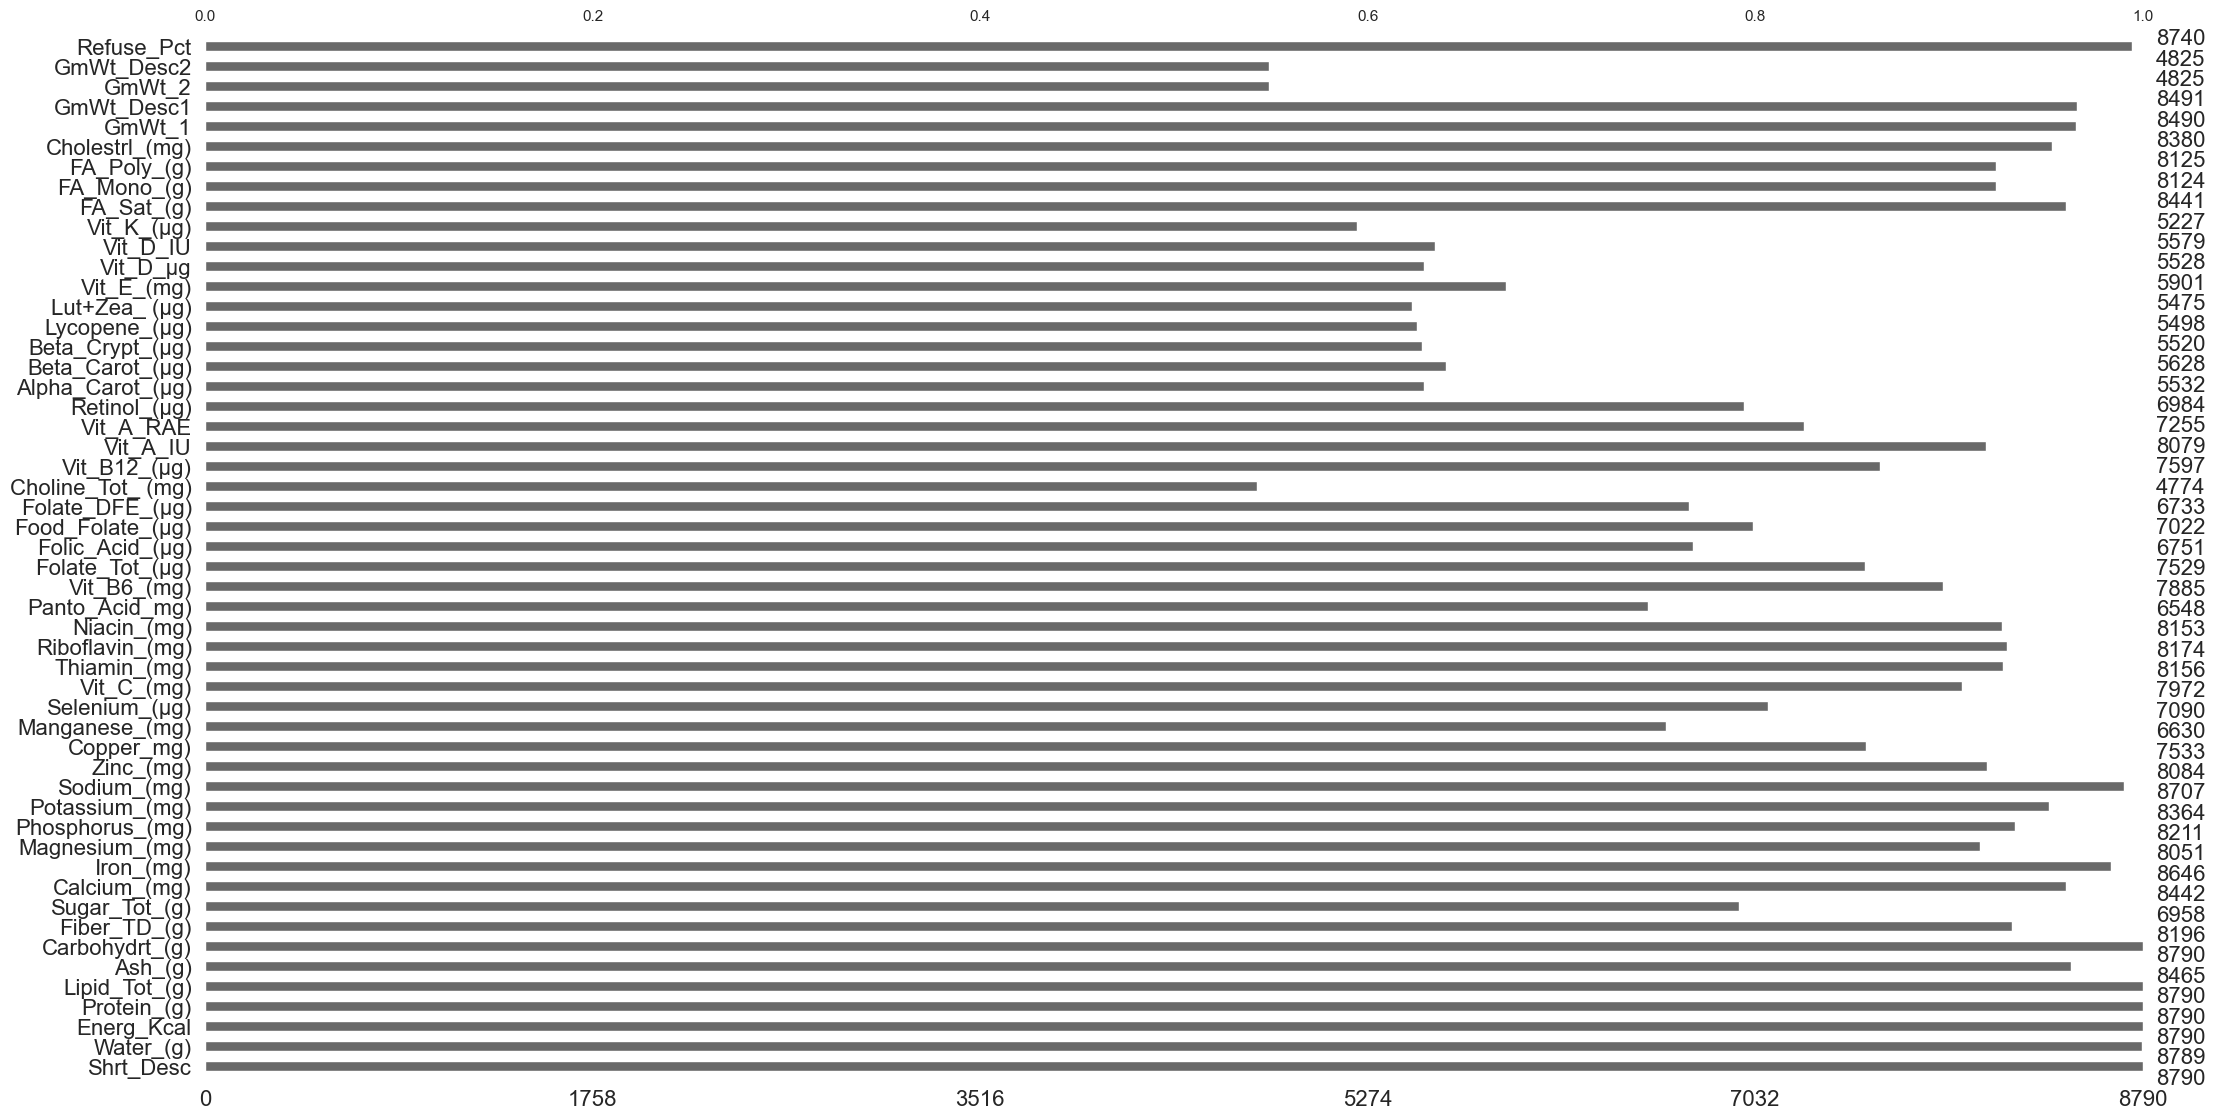

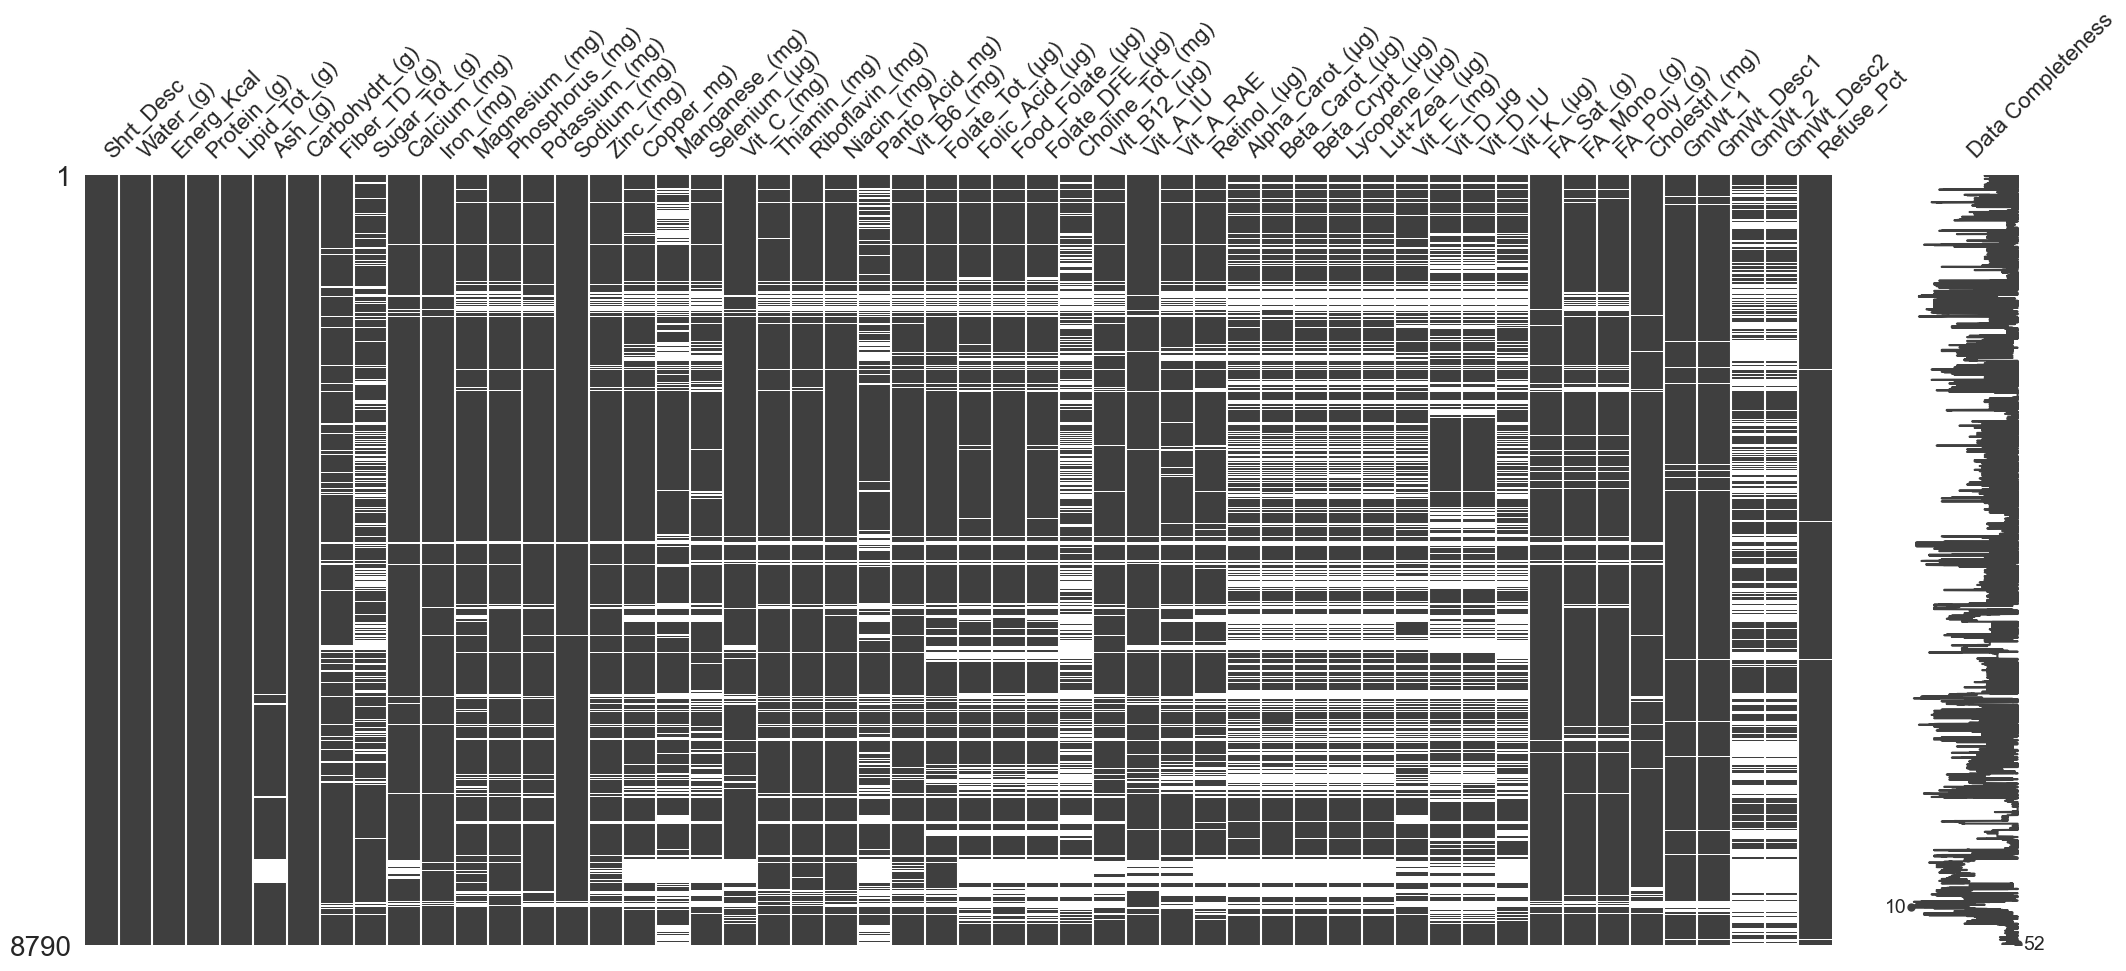

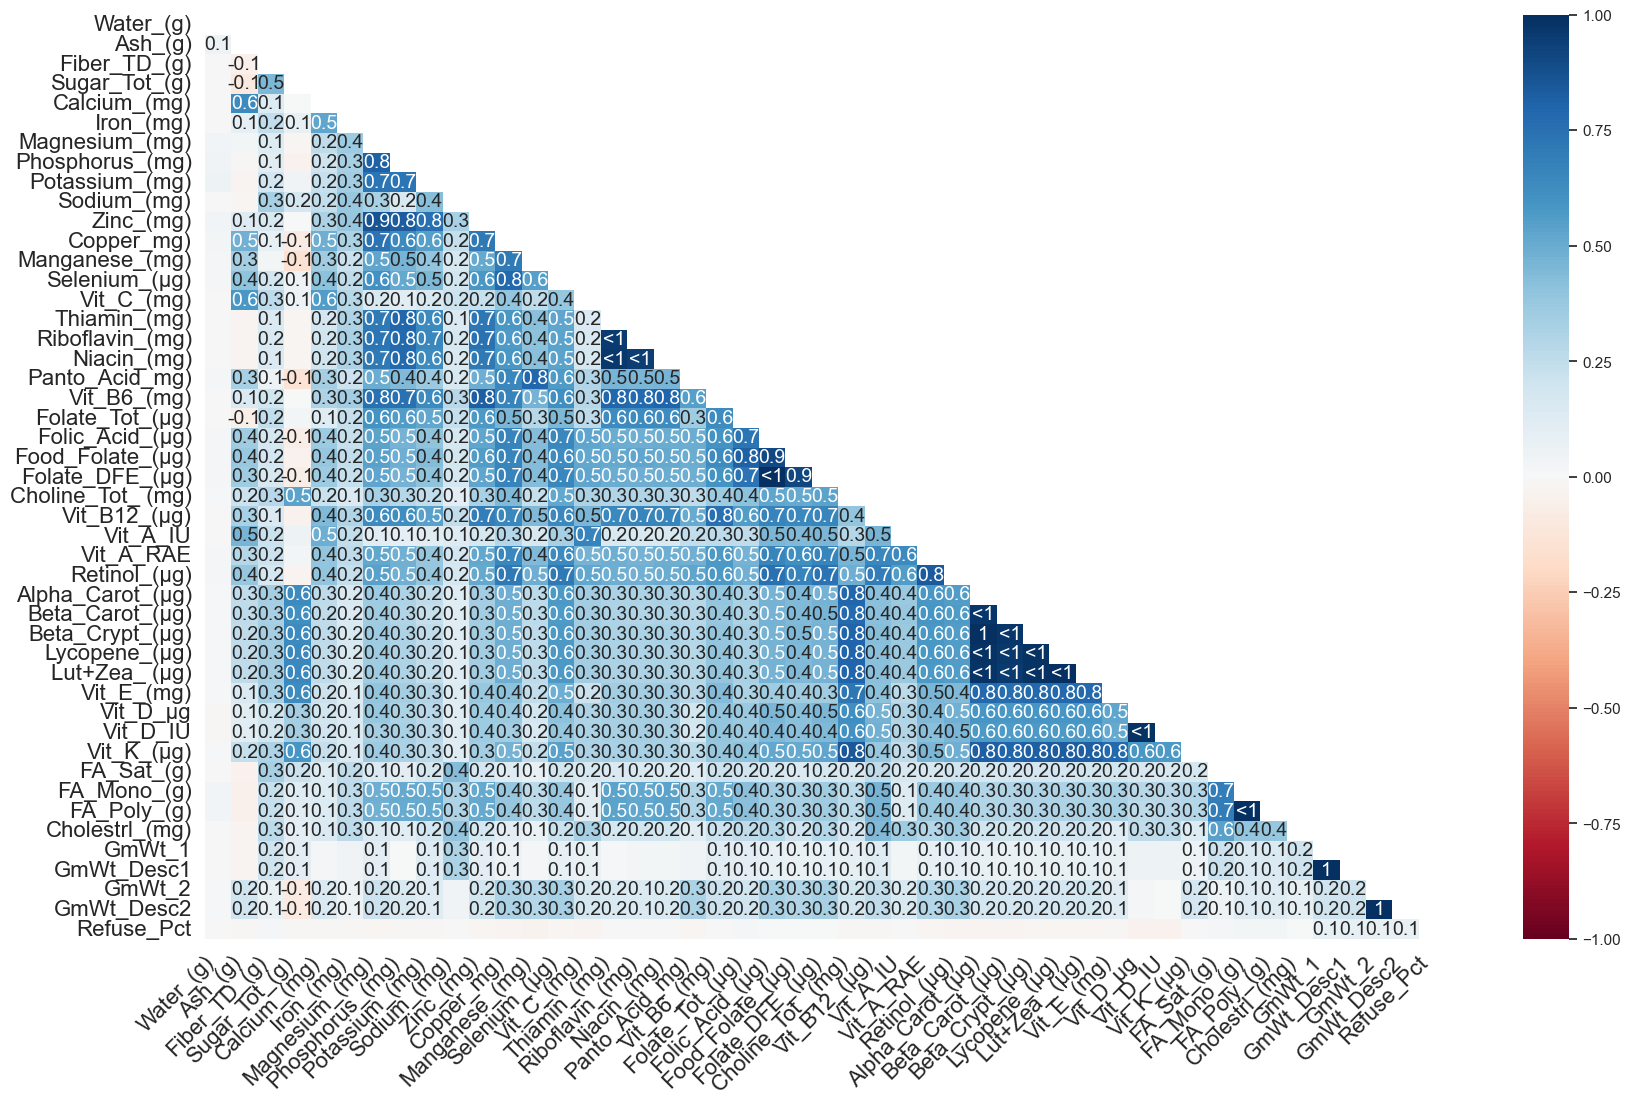

In [149]:
!pip install missingno
import missingno as msno
# Affichage des valeurs manquantes sous forme de matrice
msno.bar(df)
msno.matrix(df,labels=True)
msno.heatmap(df)

In [150]:
# Calcul du nombre de valeurs manquantes pour chaque variable
missing_values = df.isnull().sum()

# Calcul de la proportion de valeurs manquantes pour chaque variable
missing_proportions = missing_values / len(df)

# Création d'un dataframe avec les nombres et proportions de valeurs manquantes
missing_df = pd.concat([missing_values, missing_proportions], axis=1)
missing_df.columns = ['Nombre de valeurs manquantes', 'Proportion de valeurs manquantes']

# Tri des variables par ordre décroissant de proportion de valeurs manquantes
missing_df = missing_df.sort_values('Proportion de valeurs manquantes', ascending=False)

# Affichage du tableau
missing_df

,Nombre de valeurs manquantes,Proportion de valeurs manquantes
Choline_Tot_ (mg),4016,0.456883
GmWt_Desc2,3965,0.451081
GmWt_2,3965,0.451081
Vit_K_(µg),3563,0.405347
Lut+Zea_ (µg),3315,0.377133
Lycopene_(µg),3292,0.374516
Beta_Crypt_(µg),3270,0.372014
Vit_D_µg,3262,0.371104
Alpha_Carot_(µg),3258,0.370648
Vit_D_IU,3211,0.365301


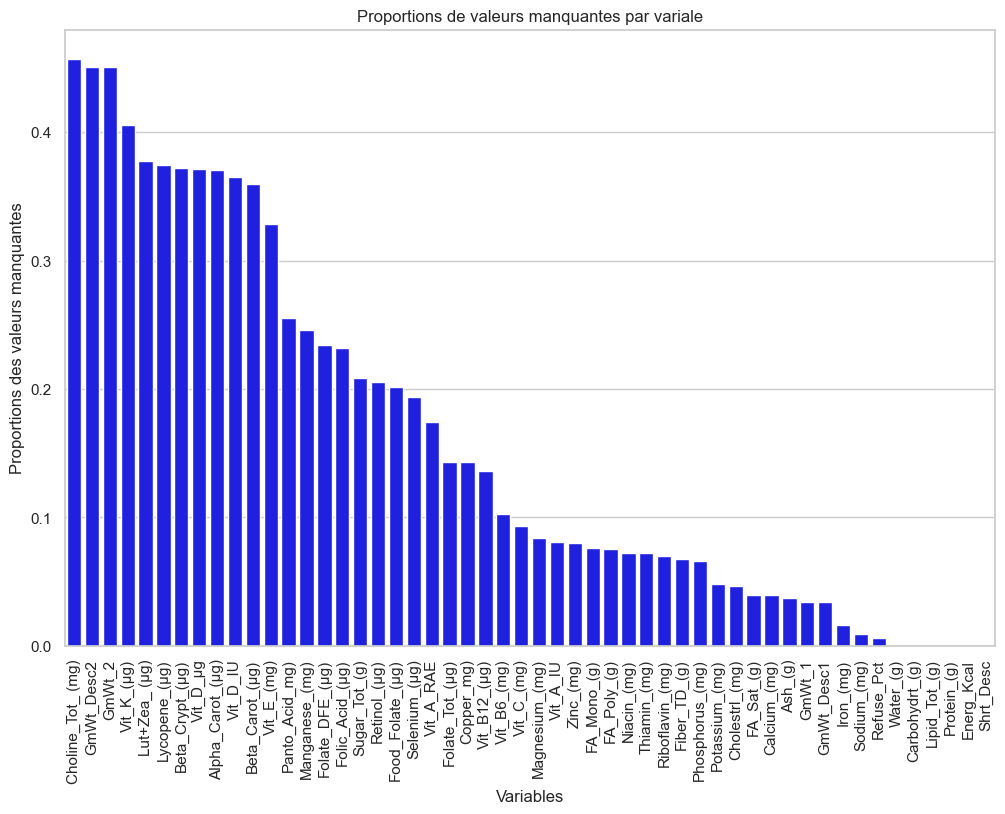

In [151]:
# Calcul de la proportion de valeurs manquantes pour chaque variable
missing_proportions = df.isnull().mean().sort_values(ascending=False)

# Creation du graphique avec Seaborn
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(x=missing_proportions.index, y=missing_proportions.values, ax= ax, color='blue')
ax.set_xlabel('Variables')
ax.set_ylabel('Proportions des valeurs manquantes')
ax.set_xticklabels(missing_proportions.index, rotation=90)
ax.set_title('Proportions de valeurs manquantes par variale')
plt.show()

# Ce graphique donne pour pour chaque variable la proportion de valeur manquante

In [152]:
# NB : si une variable a plus de 30% de valeurs manquantes, ce ne sera pas pertinent de faire des manipulations(Imputation,etc) 

## Ici on faire l'imputation de la valeurmanquante à 0

## On fait le choix de quelques nutriments qui peuvent avoir un impact sur la qualité de l'energie totale 
vars_list =['Energ_Kcal','Protein_(g)','Lipid_Tot_(g)','Carbohydrt_(g)','Fiber_TD_(g)','Calcium_(mg)','Iron_(mg)','Sodium_(mg)','Water_(g)','Magnesium_(mg)','Phosphorus_(mg)','Vit_C_(mg)','FA_Sat_(g)','FA_Mono_(g)','FA_Poly_(g)']

# Calcul de la proportion de valeurs manquantes pour chaque variable dans la liste
missing_prop = df[vars_list].isna().mean().reset_index()

# Renommage des colonnes
missing_prop.columns = ['variable', 'missing_prop']

# Tri par ordre décroissant de la proportion de valeurs manquantes
missing_prop = missing_prop.sort_values('missing_prop', ascending=False)

# Affichage du resultat
print(missing_prop)

           variable  missing_prop
11       Vit_C_(mg)      0.093060
9    Magnesium_(mg)      0.084073
13      FA_Mono_(g)      0.075768
14      FA_Poly_(g)      0.075654
4      Fiber_TD_(g)      0.067577
10  Phosphorus_(mg)      0.065870
12       FA_Sat_(g)      0.039704
5      Calcium_(mg)      0.039590
6         Iron_(mg)      0.016382
7       Sodium_(mg)      0.009443
8         Water_(g)      0.000114
0        Energ_Kcal      0.000000
1       Protein_(g)      0.000000
2     Lipid_Tot_(g)      0.000000
3    Carbohydrt_(g)      0.000000


In [153]:
# Extraction de la base de données liés aux variables considérées

keep_vars=['Shrt_Desc','Energ_Kcal','Protein_(g)','Lipid_Tot_(g)','Carbohydrt_(g)','Fiber_TD_(g)','Calcium_(mg)','Iron_(mg)','Sodium_(mg)','Water_(g)','Magnesium_(mg)','Phosphorus_(mg)','Vit_C_(mg)','FA_Sat_(g)','FA_Mono_(g)','FA_Poly_(g)']

# Sélection des colonnes de la base de données correspondant aux variables sélectionnées
df_restrict = df[keep_vars]

# Affichage des 10 premières lignes de la base de données modifiée
df_restrict.head(10)

,Shrt_Desc,Energ_Kcal,Protein_(g),Lipid_Tot_(g),Carbohydrt_(g),Fiber_TD_(g),Calcium_(mg),Iron_(mg),Sodium_(mg),Water_(g),Magnesium_(mg),Phosphorus_(mg),Vit_C_(mg),FA_Sat_(g),FA_Mono_(g),FA_Poly_(g)
NDB_No,,,,,,,,,,,,,,,,
1001,"BUTTER,WITH SALT",717,0.85,81.11,0.06,0.0,24.0,0.02,643.0,15.87,2.0,24.0,0.0,51.368,21.021,3.043
1002,"BUTTER,WHIPPED,W/ SALT",718,0.49,78.30,2.87,0.0,23.0,0.05,583.0,16.72,1.0,24.0,0.0,45.390,19.874,3.331
1003,"BUTTER OIL,ANHYDROUS",876,0.28,99.48,0.00,0.0,4.0,0.00,2.0,0.24,0.0,3.0,0.0,61.924,28.732,3.694
1004,"CHEESE,BLUE",353,21.40,28.74,2.34,0.0,528.0,0.31,1146.0,42.41,23.0,387.0,0.0,18.669,7.778,0.800
1005,"CHEESE,BRICK",371,23.24,29.68,2.79,0.0,674.0,0.43,560.0,41.11,24.0,451.0,0.0,18.764,8.598,0.784
1006,"CHEESE,BRIE",334,20.75,27.68,0.45,0.0,184.0,0.50,629.0,48.42,20.0,188.0,0.0,17.410,8.013,0.826
1007,"CHEESE,CAMEMBERT",300,19.80,24.26,0.46,0.0,388.0,0.33,842.0,51.80,20.0,347.0,0.0,15.259,7.023,0.724
1008,"CHEESE,CARAWAY",376,25.18,29.20,3.06,0.0,673.0,0.64,690.0,39.28,22.0,490.0,0.0,18.584,8.275,0.830
1009,"CHEESE,CHEDDAR",404,22.87,33.31,3.09,0.0,710.0,0.14,653.0,37.02,27.0,455.0,0.0,18.867,9.246,1.421


In [154]:
## Traitement des valeurs manquantes: on remplace ici les valeurs manquantes par zéro car on ne peut pas avoir 
## tous les nutriments dans tous les elements

# Remplacement des aleurs manquantes par zero
df_miss = df_restrict.fillna(0)

# Affichage des 10 premieres lignes de la base de données
df_miss.head()

,Shrt_Desc,Energ_Kcal,Protein_(g),Lipid_Tot_(g),Carbohydrt_(g),Fiber_TD_(g),Calcium_(mg),Iron_(mg),Sodium_(mg),Water_(g),Magnesium_(mg),Phosphorus_(mg),Vit_C_(mg),FA_Sat_(g),FA_Mono_(g),FA_Poly_(g)
NDB_No,,,,,,,,,,,,,,,,
1001,"BUTTER,WITH SALT",717,0.85,81.11,0.06,0.0,24.0,0.02,643.0,15.87,2.0,24.0,0.0,51.368,21.021,3.043
1002,"BUTTER,WHIPPED,W/ SALT",718,0.49,78.30,2.87,0.0,23.0,0.05,583.0,16.72,1.0,24.0,0.0,45.390,19.874,3.331
1003,"BUTTER OIL,ANHYDROUS",876,0.28,99.48,0.00,0.0,4.0,0.00,2.0,0.24,0.0,3.0,0.0,61.924,28.732,3.694
1004,"CHEESE,BLUE",353,21.40,28.74,2.34,0.0,528.0,0.31,1146.0,42.41,23.0,387.0,0.0,18.669,7.778,0.800
1005,"CHEESE,BRICK",371,23.24,29.68,2.79,0.0,674.0,0.43,560.0,41.11,24.0,451.0,0.0,18.764,8.598,0.784


In [155]:
# Calcul du nombre de valeurs manquantes pour chaque variable
missing_values = df_miss.isnull().sum()

# Calcul de la proportion de valeurs manquantes pour chaque variable
missing_proportions = missing_values / len(df)

# Creation d'un dataframe avec les nombres et proportions e valeurs manquantes
missing_df = pd.concat([missing_values, missing_proportions], axis=1)
missing_df.columns = ['Nombre de valeurs manquantes', 'Proportion de valeurs manquantes']

# Tri des variables par ordre décroissant de proportion de valeurs manquantes
missing_df.sort_values('Proportion de valeurs manquantes', ascending = False)

# Affichage du tableau
missing_df

,Nombre de valeurs manquantes,Proportion de valeurs manquantes
Shrt_Desc,0,0.0
Energ_Kcal,0,0.0
Protein_(g),0,0.0
Lipid_Tot_(g),0,0.0
Carbohydrt_(g),0,0.0
Fiber_TD_(g),0,0.0
Calcium_(mg),0,0.0
Iron_(mg),0,0.0
Sodium_(mg),0,0.0
Water_(g),0,0.0


#### 2. Analyses descriptives univariées

In [157]:
# Analyse descriptive du jeu de données
Description = df_miss.describe()
print(Description)

        Energ_Kcal  Protein_(g)  Lipid_Tot_(g)  Carbohydrt_(g)  Fiber_TD_(g)  \
count  8790.000000  8790.000000    8790.000000     8790.000000   8790.000000   
mean    226.317634    11.342849      10.553725       22.127710      2.039625   
std     169.877539    10.530474      15.814842       27.270822      4.267904   
min       0.000000     0.000000       0.000000        0.000000      0.000000   
25%      91.000000     2.380000       0.950000        0.050000      0.000000   
50%     191.000000     8.000000       5.140000        9.340000      0.400000   
75%     337.000000    19.880000      13.720000       34.910000      2.400000   
max     902.000000    88.320000     100.000000      100.000000     79.000000   

       Calcium_(mg)    Iron_(mg)   Sodium_(mg)    Water_(g)  Magnesium_(mg)  \
count   8790.000000  8790.000000   8790.000000  8790.000000     8790.000000   
mean      73.700114     2.655447    309.545165    54.106061       32.328555   
std      200.017998     5.651177    939.45

Energ_Kcal


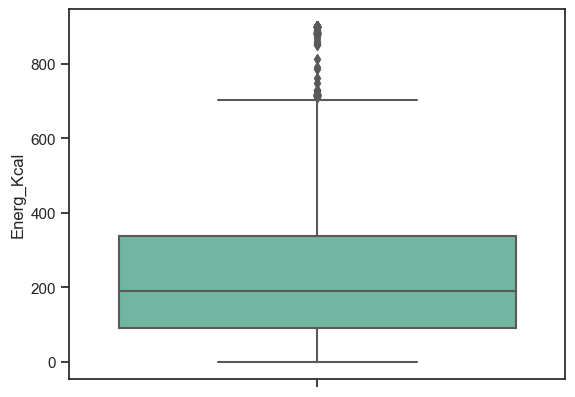

Protein_(g)


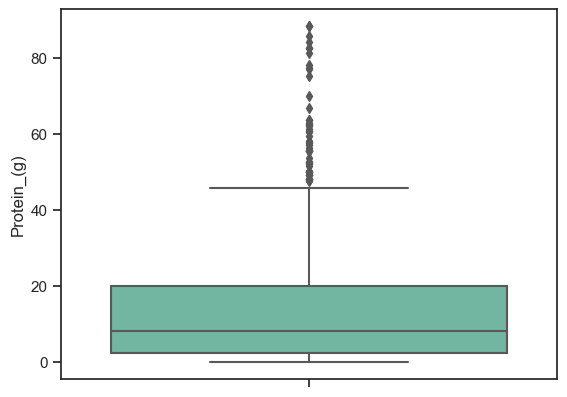

Lipid_Tot_(g)


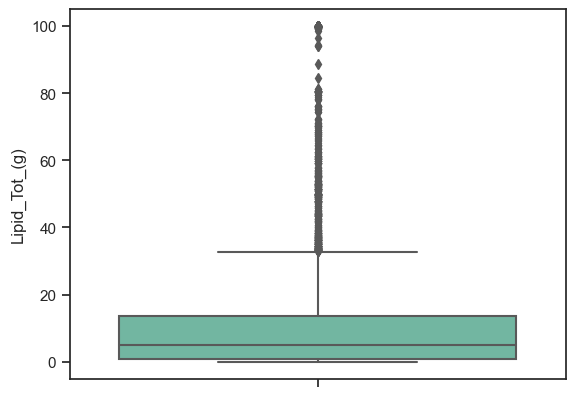

Carbohydrt_(g)


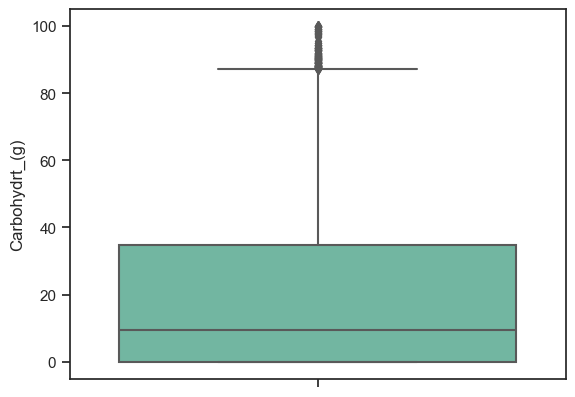

Fiber_TD_(g)


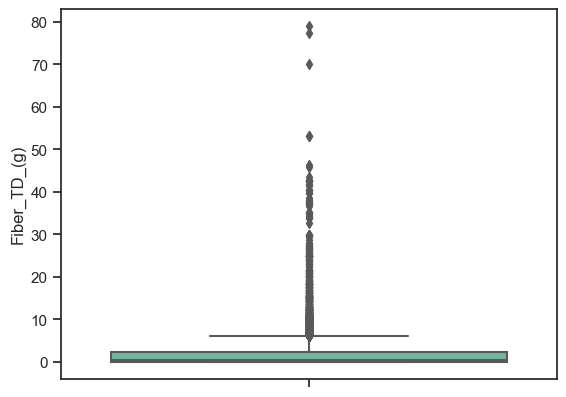

Calcium_(mg)


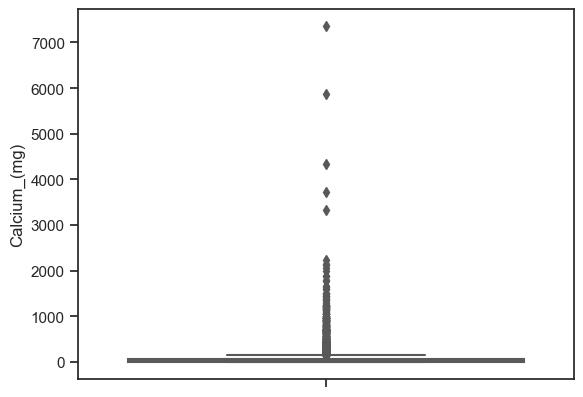

Iron_(mg)


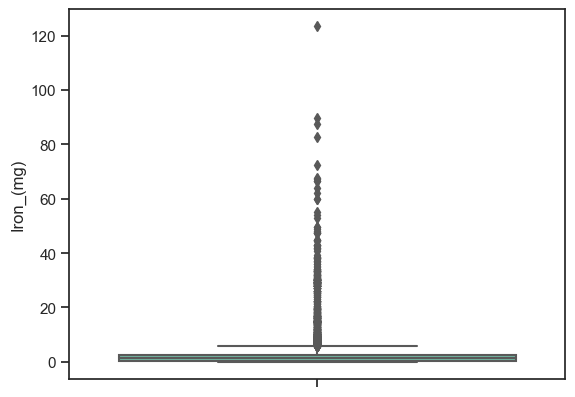

Sodium_(mg)


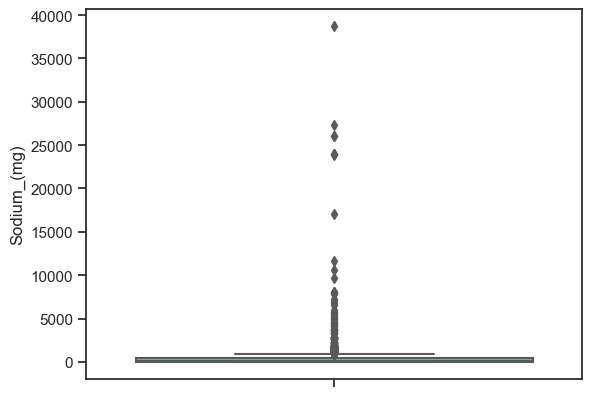

Water_(g)


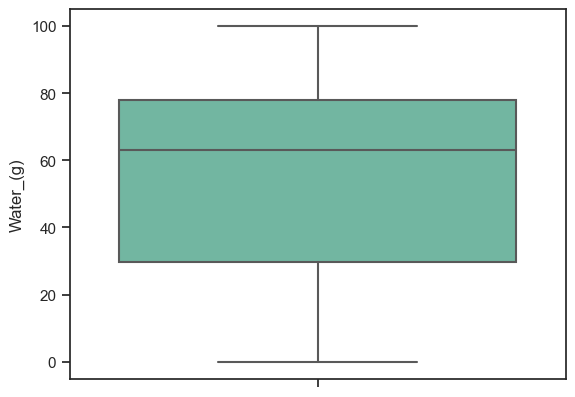

Magnesium_(mg)


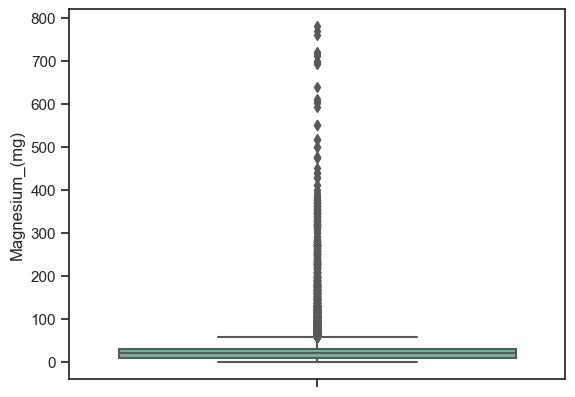

Phosphorus_(mg)


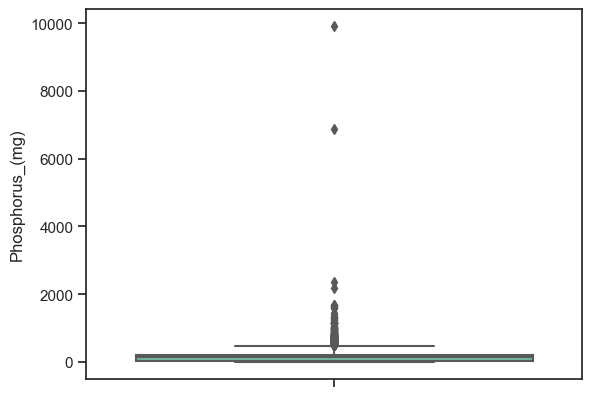

Vit_C_(mg)


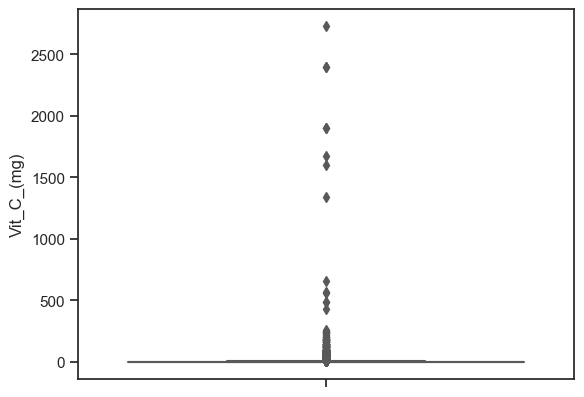

FA_Sat_(g)


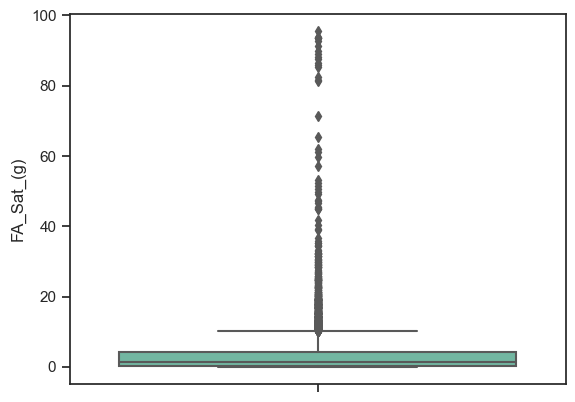

FA_Mono_(g)


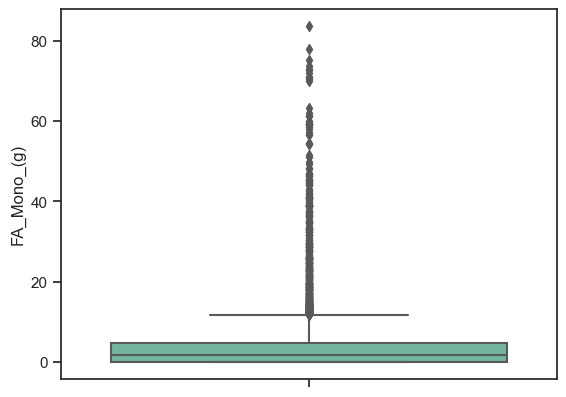

FA_Poly_(g)


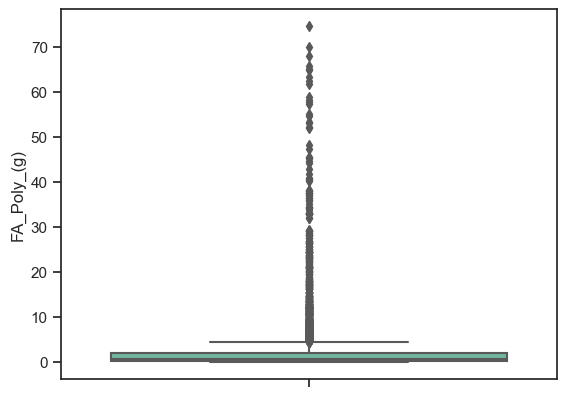

In [158]:
# Analyse descriptive des variablesquabtitatives
# Selection des variables quantitatives
quant_vars = df_miss.select_dtypes(include = ['float64', 'int64'])

# Tracé des boxplots pour chaque variable quantitative avec Seaborn
sns.set(style='ticks')
for var in quant_vars:
    print(var)
    sns.boxplot(y=var, data=quant_vars, palette="Set2")
    plt.show()



C:\Users\brech\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\brech\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\brech\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\brech\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

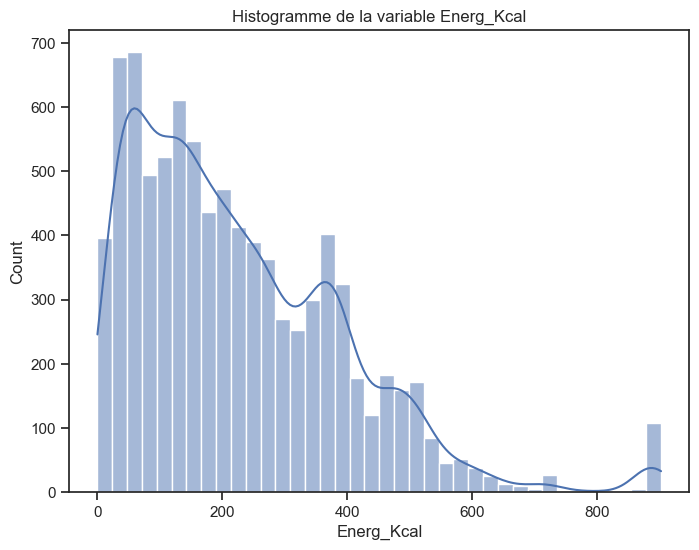

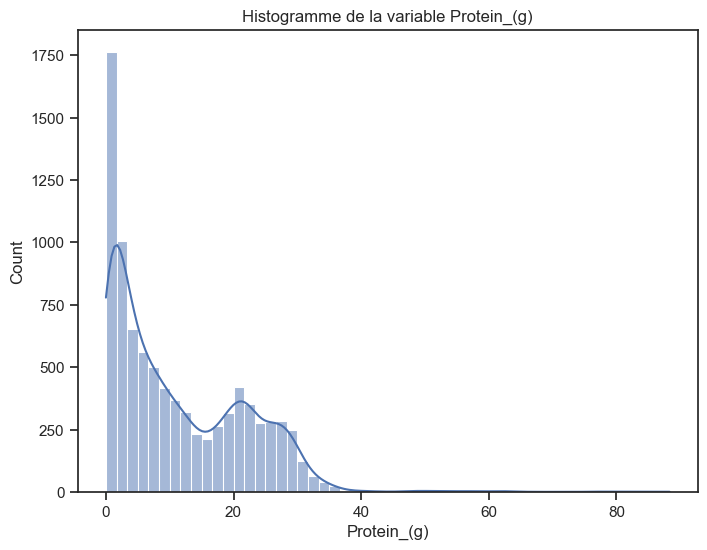

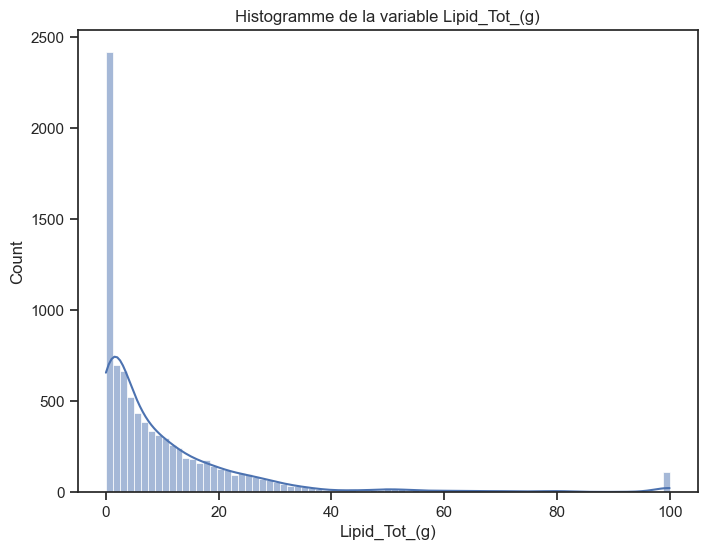

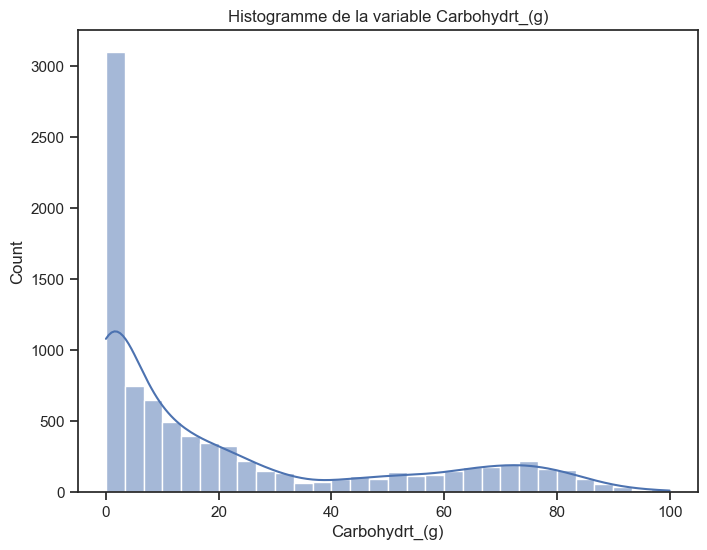

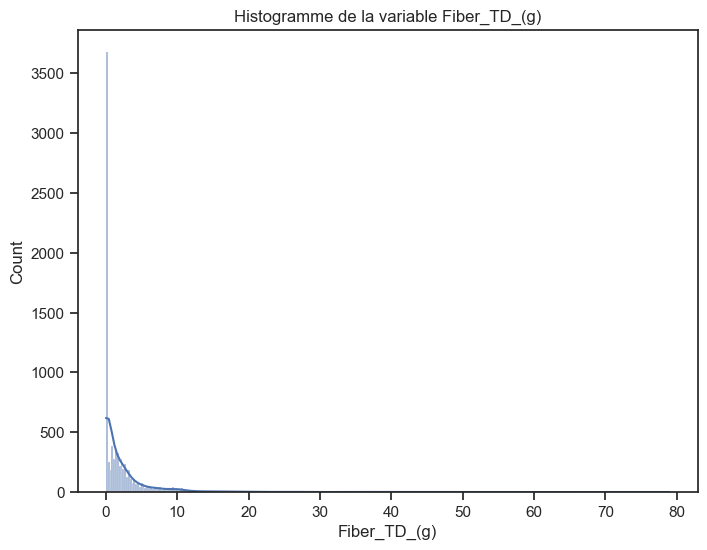

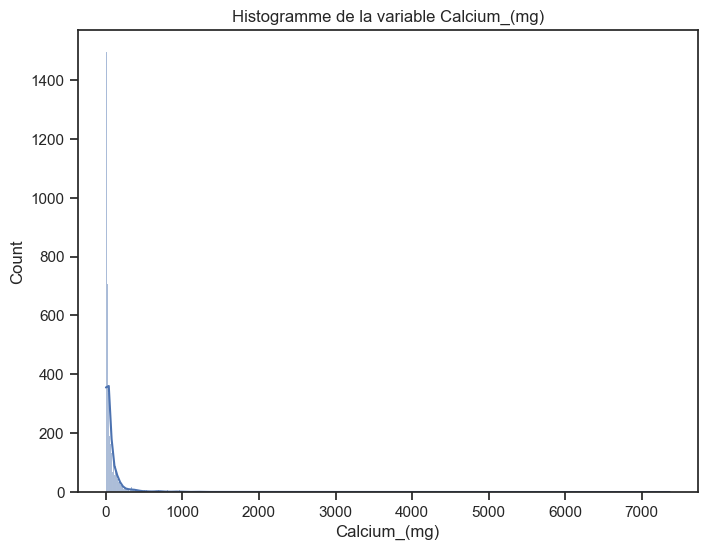

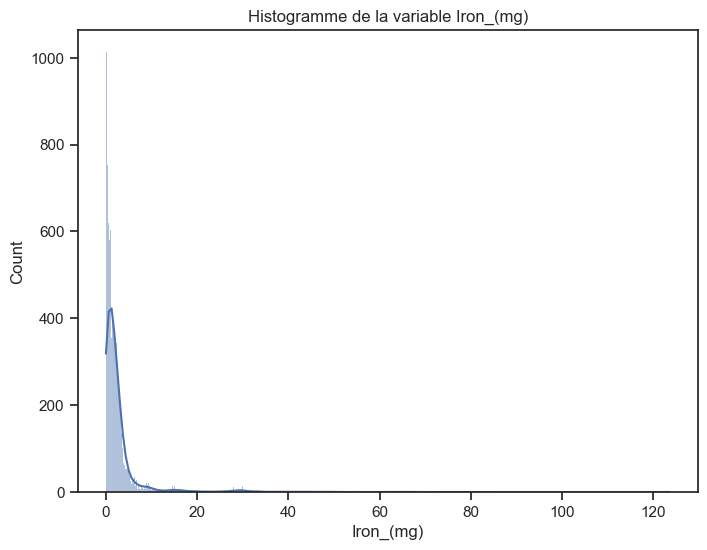

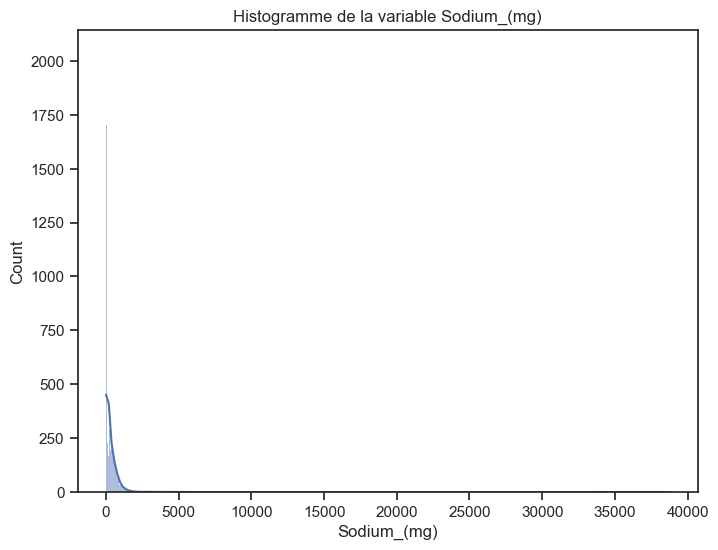

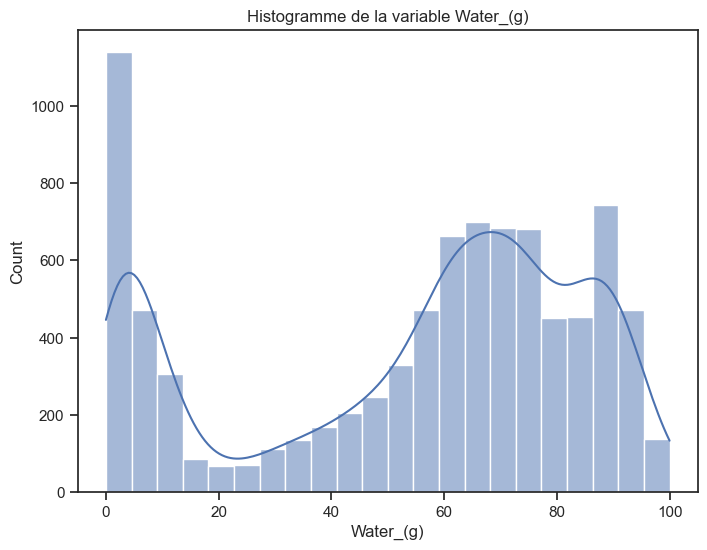

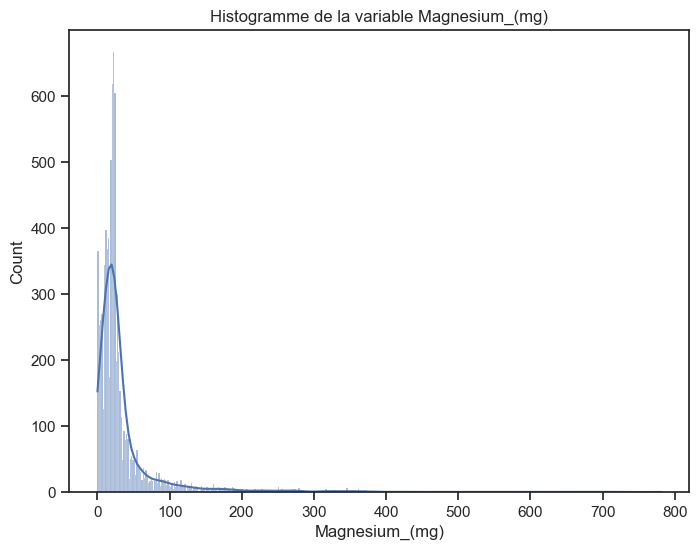

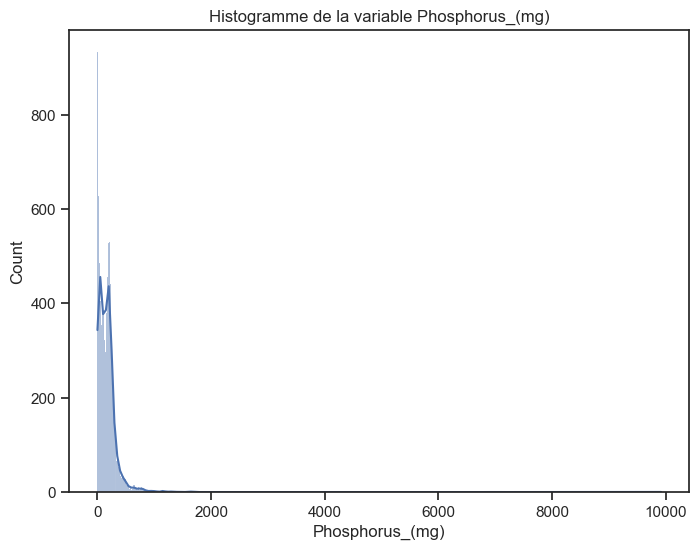

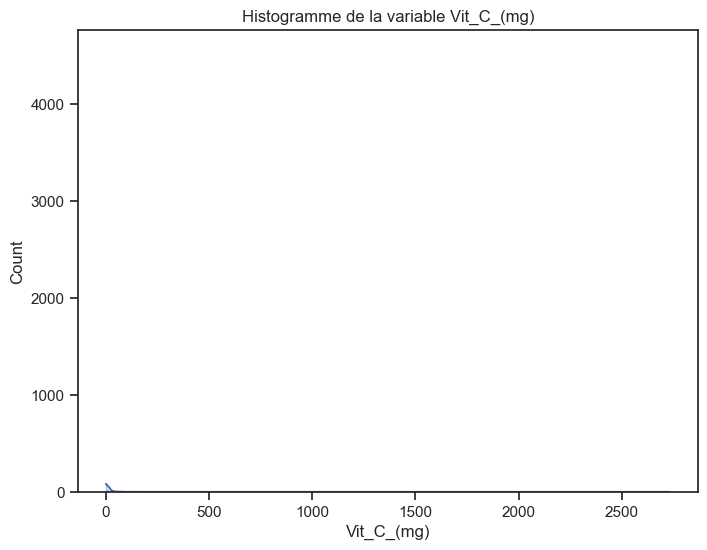

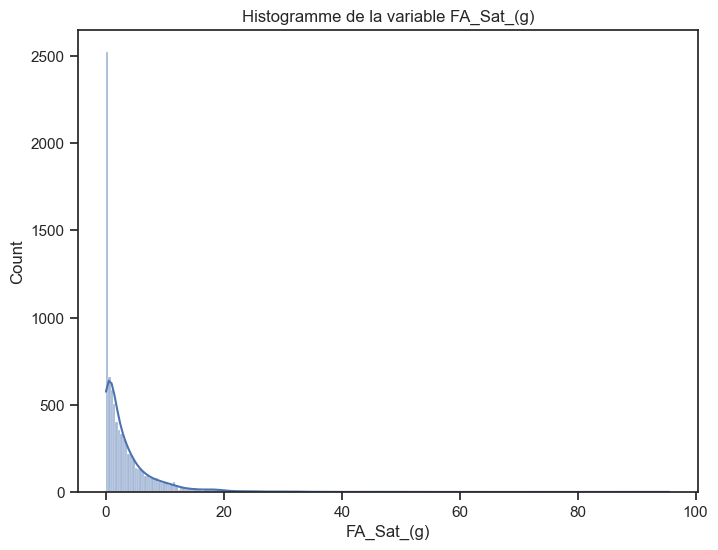

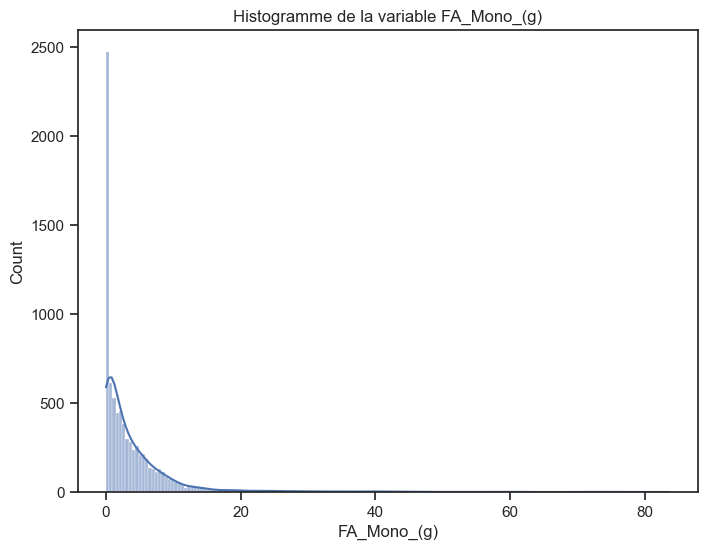

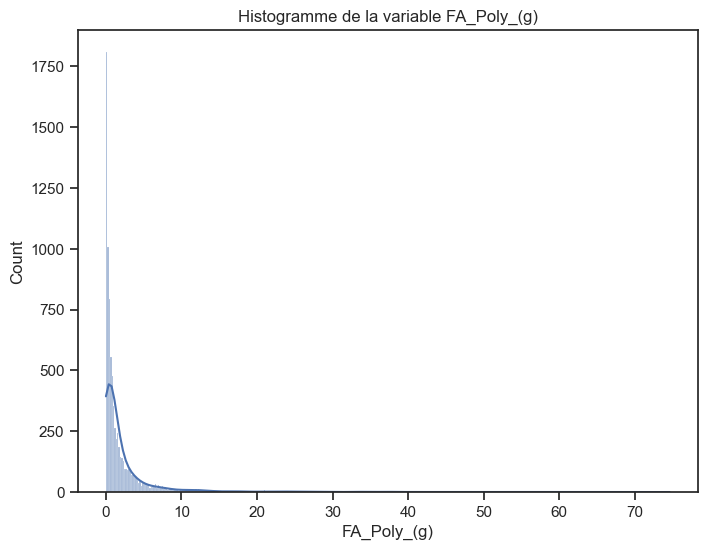

In [159]:
# Analyse de la normalité 

from scipy.stats import shapiro

# Creation d'un  histogramme et d'un test de normalité pour chaque variable
for column in quant_vars:
    plt.figure(figsize=(8, 6))
    sns.histplot(data=df, x=column, kde=True)
    plt.title(f"Histogramme de la variable {column}")
    plt.show
    

In [160]:
# Initialisation du DataFrame pour les résultats des tests de normalité
normality_results = []

# Boucle pour calculer les tests de normalité pour chaque variable quantitative
for var in quant_vars.columns:  # Assurez-vous que quant_vars est un DataFrame
    stat, p = shapiro(quant_vars[var])  # Test de Shapiro-Wilk
    normality = 'Normal' if p > 0.05 else 'Not Normal'  # p > 0.05 => Normalité acceptée
    normality_results.append({'Variable': var, 'P-value': p, 'Normality': normality})

# Création du DataFrame final
normality_df = pd.DataFrame(normality_results)

# Affichage du DataFrame des résultats des tests de normalité
print(normality_df)


           Variable  P-value   Normality
0        Energ_Kcal      0.0  Not Normal
1       Protein_(g)      0.0  Not Normal
2     Lipid_Tot_(g)      0.0  Not Normal
3    Carbohydrt_(g)      0.0  Not Normal
4      Fiber_TD_(g)      0.0  Not Normal
5      Calcium_(mg)      0.0  Not Normal
6         Iron_(mg)      0.0  Not Normal
7       Sodium_(mg)      0.0  Not Normal
8         Water_(g)      0.0  Not Normal
9    Magnesium_(mg)      0.0  Not Normal
10  Phosphorus_(mg)      0.0  Not Normal
11       Vit_C_(mg)      0.0  Not Normal
12       FA_Sat_(g)      0.0  Not Normal
13      FA_Mono_(g)      0.0  Not Normal
14      FA_Poly_(g)      0.0  Not Normal


C:\Users\brech\anaconda3\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


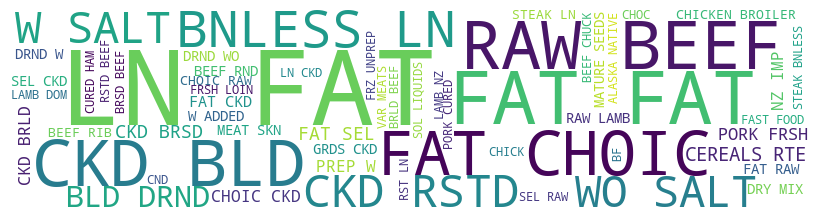

In [161]:
## Analyse de la descrption des produits
!pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Concatener toutes les chaines de caracteres dans la variable Shrt_Desc en une seule chaine
text = ' '.join(df_miss['Shrt_Desc'])

# Generer le word cloud
wordcloud = WordCloud(width=800, background_color='white', min_font_size=10).generate(text)

# Afficher le word cloud
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

In [162]:
# Plus la taille est grosse, plus la frequence du produit est important

#### 3. Analyse bivariée

C:\Users\brech\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\brech\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\brech\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\brech\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

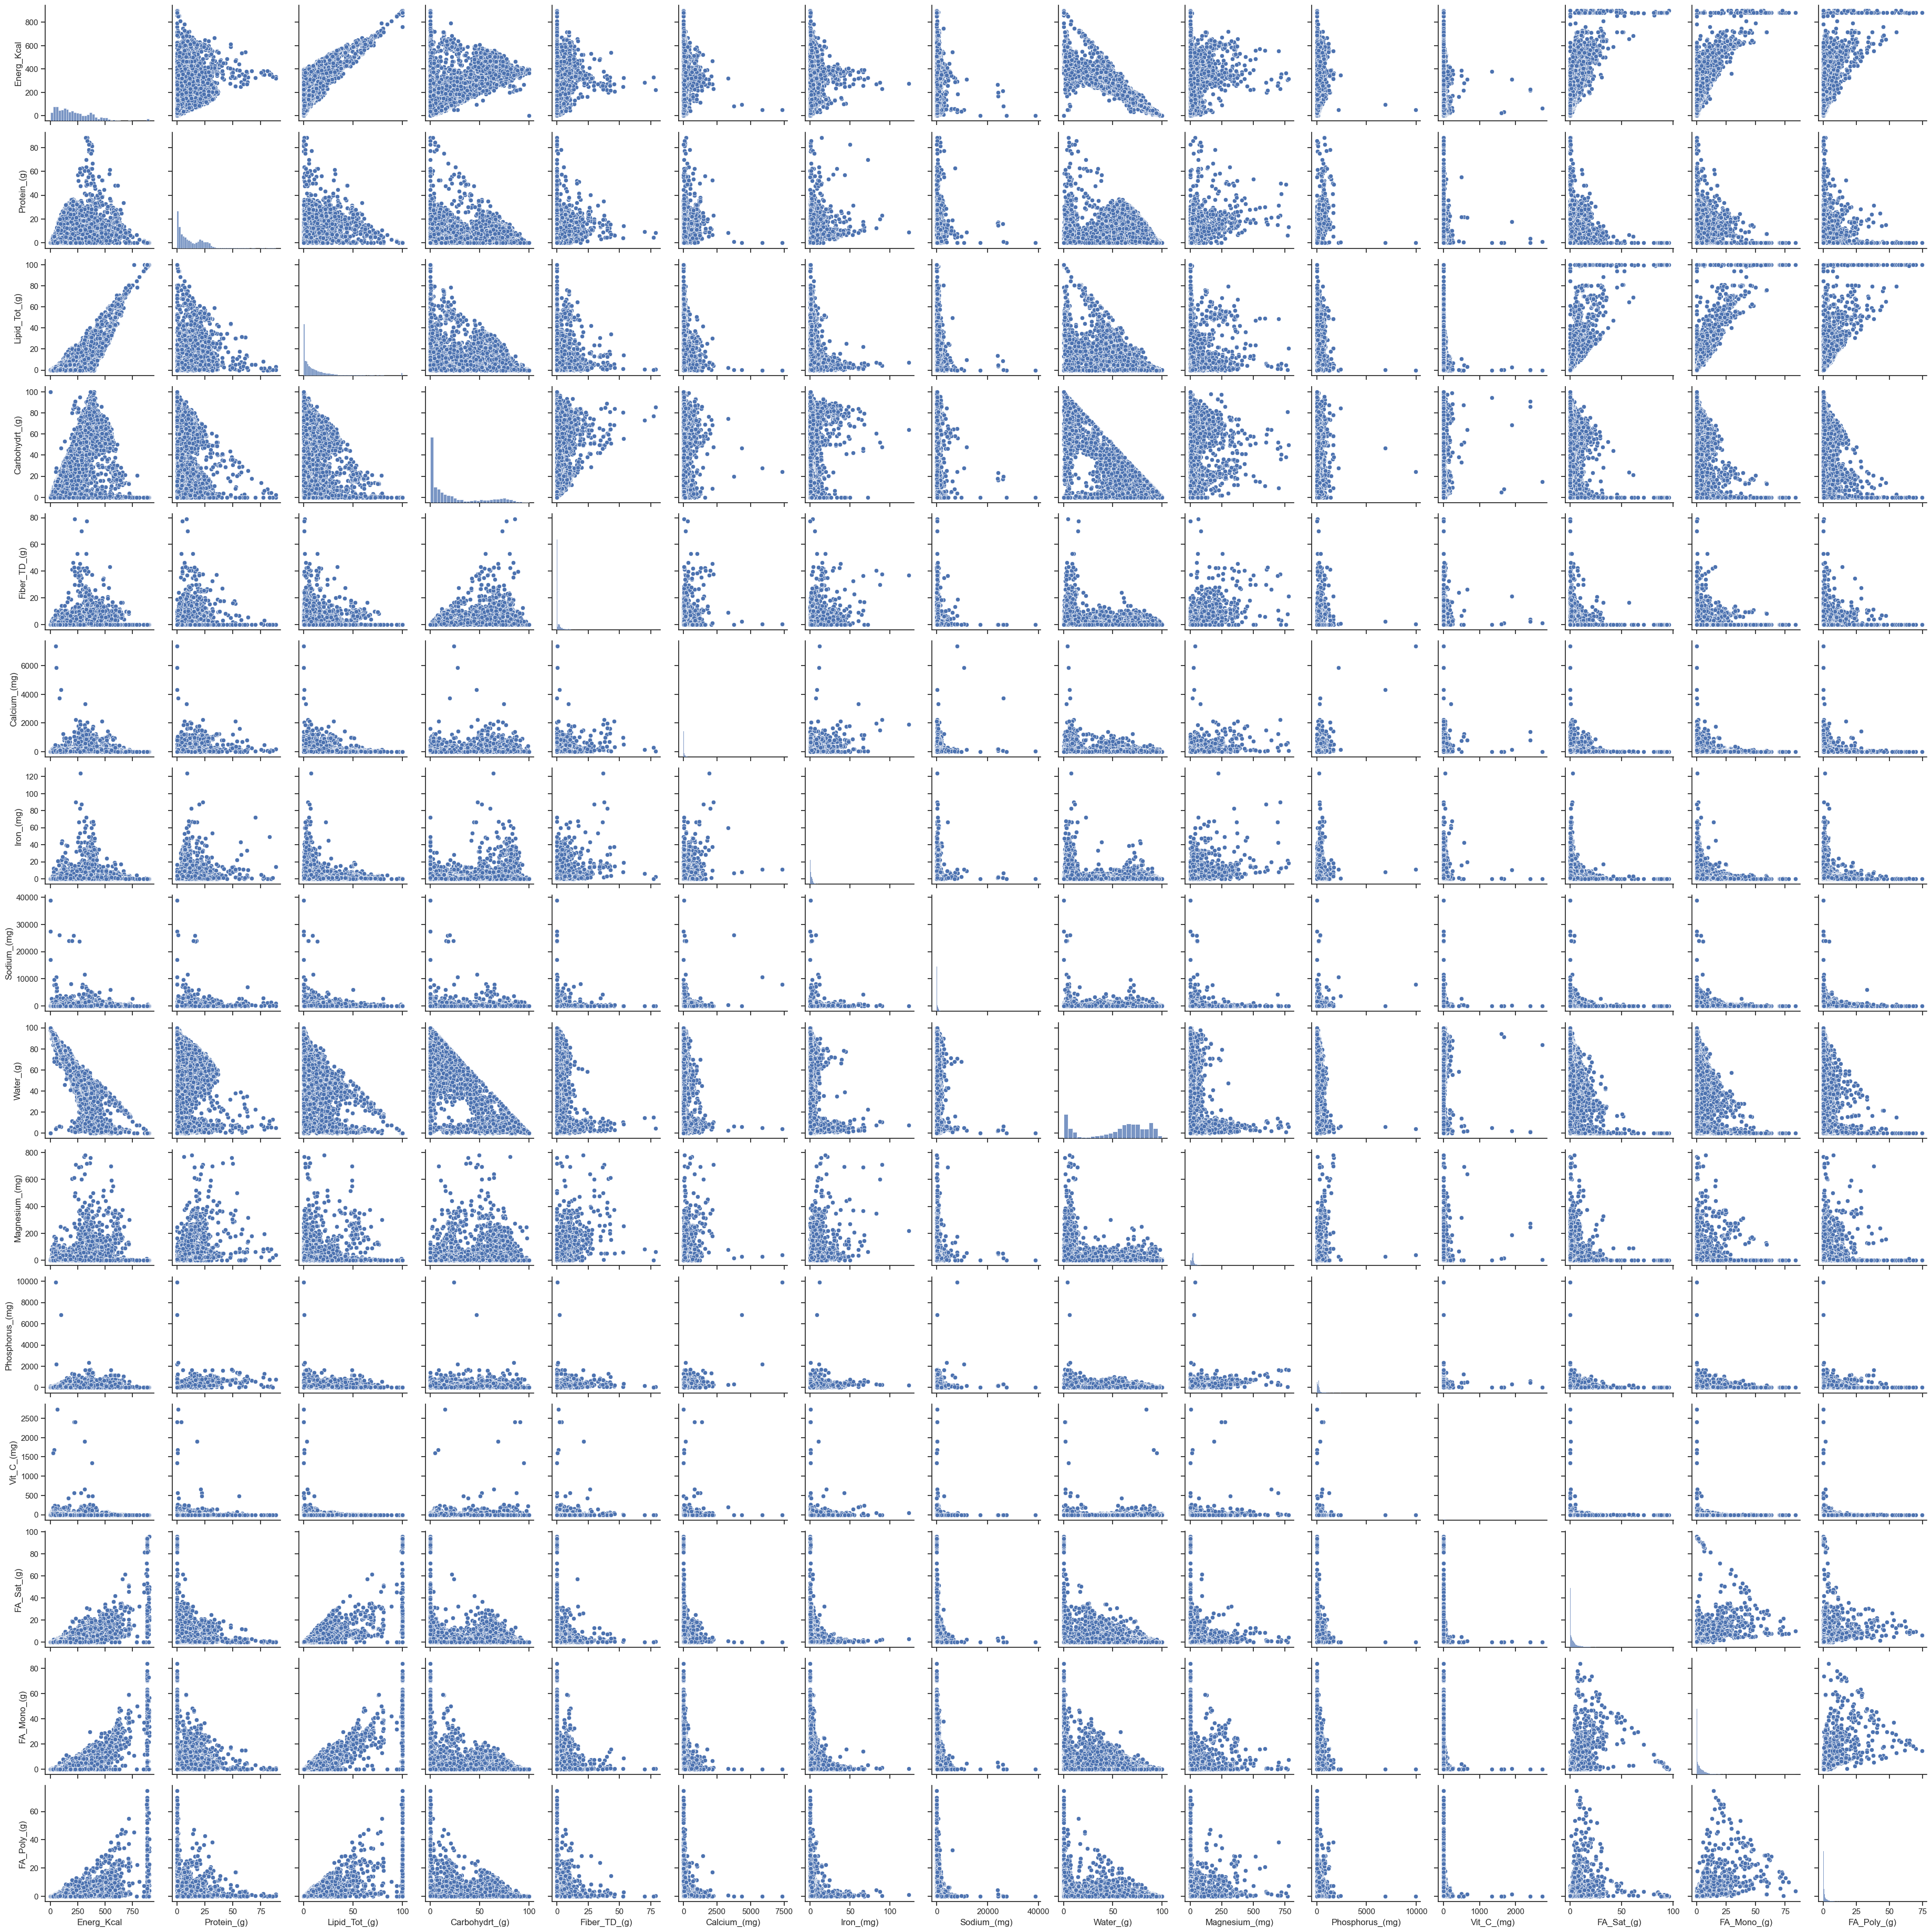

In [164]:
# Relation entre les variables quantitatives

sns.pairplot(df_miss)

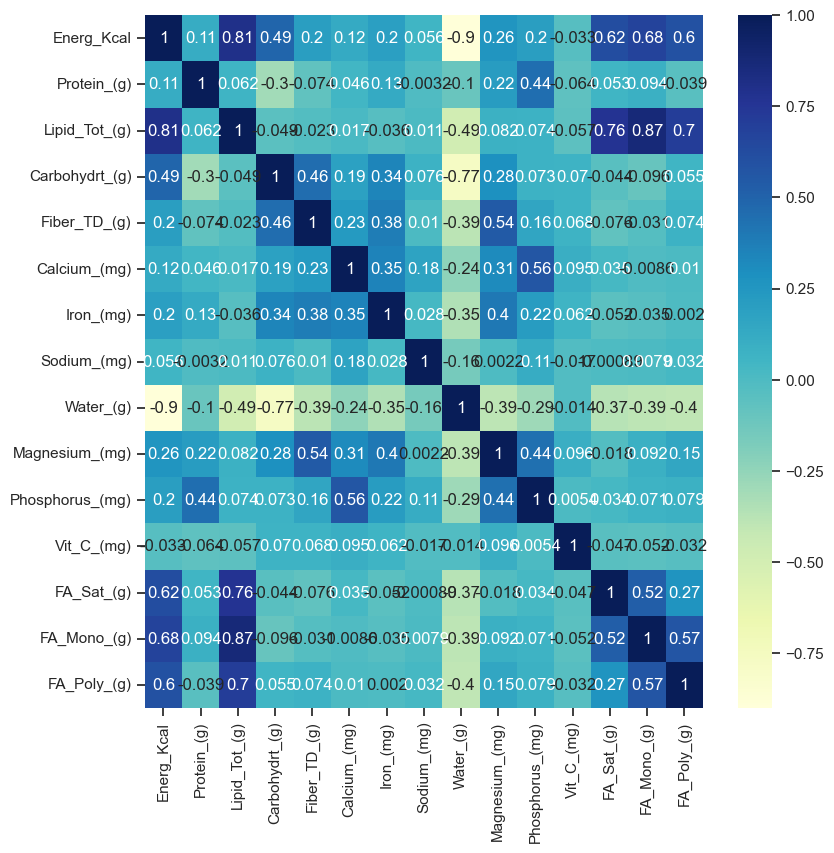

In [165]:
# Obtenir le tableau de correlation et la heatmap (corrélation de pearson)
df_numeric = df_miss.select_dtypes(include=[np.number])  # Garde uniquement les colonnes numériques
corr_matrix = df_numeric.corr()

# Calcul des p_values pour chaque paire de variables
fig, ax = plt.subplots(figsize=(9, 9))
sns.heatmap(corr_matrix,annot=True,cmap="YlGnBu")
plt.show()

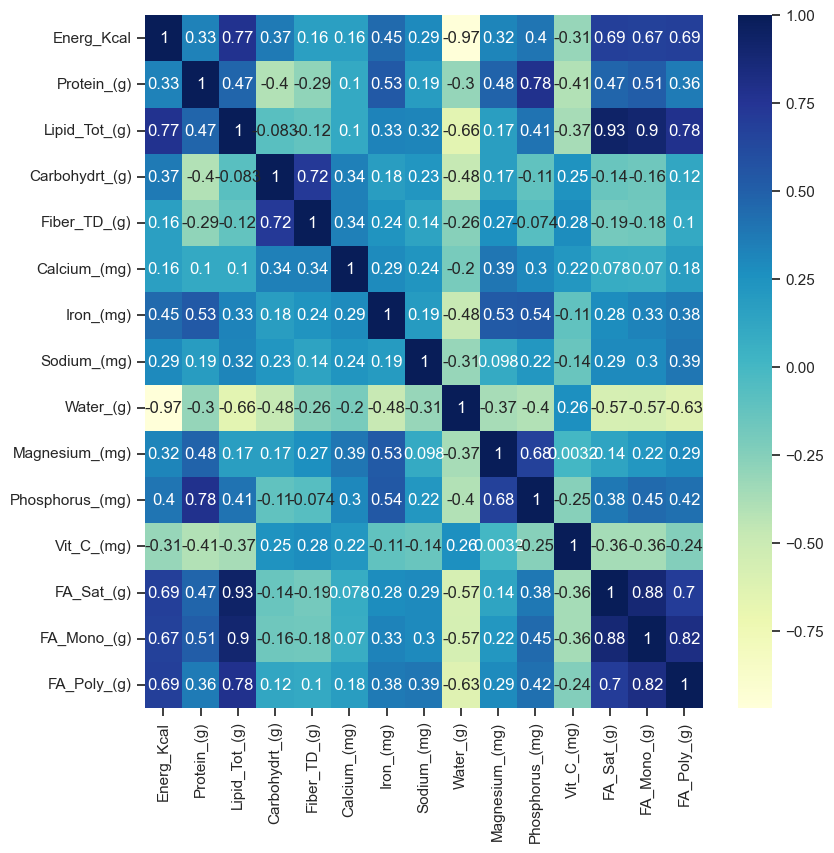

In [166]:
# Obtenir le tableau de corrélation et la heatmap (correlation de spearman, rappel: pour les relartions non lineaire)

df_numeric = df_miss.select_dtypes(include=[np.number])  
corr_matrix = df_numeric.corr(method='spearman')
# Calcul des p-values pour chaque paire de variables
fig, ax = plt.subplots(figsize=(9,9))
sns.heatmap(corr_matrix, annot=True, cmap="YlGnBu")
plt.show()

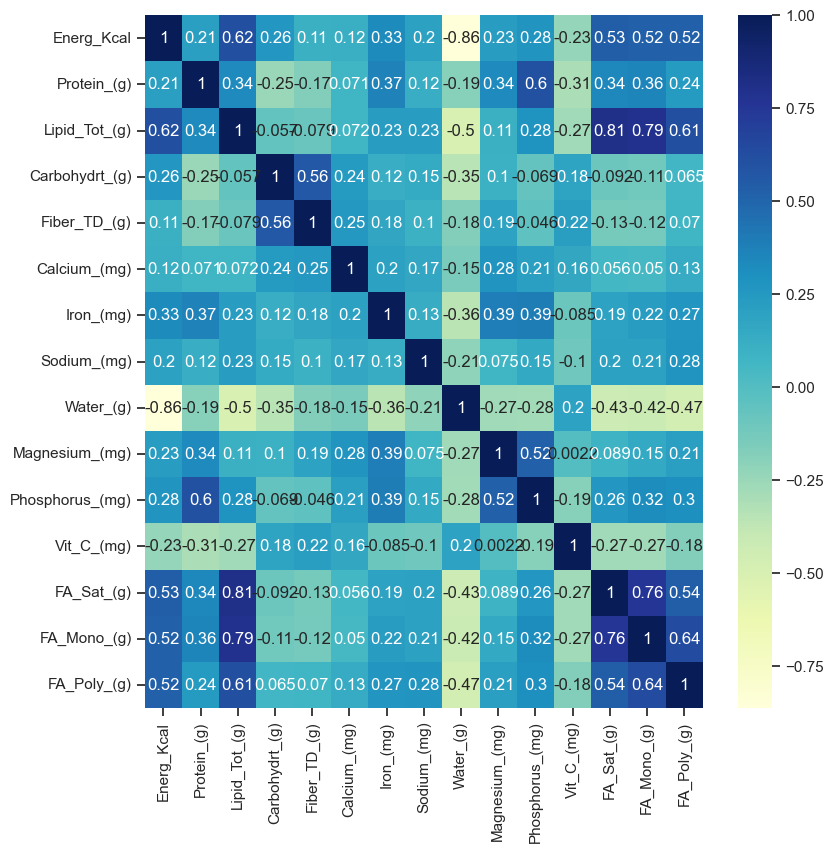

In [167]:
# Obtenir le tableau de corrélation et la heatmap (correlation de Kendall)

df_numeric = df_miss.select_dtypes(include=[np.number])  
corr_matrix = df_numeric.corr(method='kendall')
# Calcul des p-values pour chaque paire de variables
fig, ax = plt.subplots(figsize=(9,9))
sns.heatmap(corr_matrix, annot=True, cmap="YlGnBu")
plt.show()

#### Au nieau multivarié ( Construction de l'ACP)

In [169]:
df = df_miss

In [170]:
## Separation des données en variables quantitatives (X) et variable qualitative(Y)
x = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [171]:
x

array([[7.1700e+02, 8.5000e-01, 8.1110e+01, ..., 5.1368e+01, 2.1021e+01,
        3.0430e+00],
       [7.1800e+02, 4.9000e-01, 7.8300e+01, ..., 4.5390e+01, 1.9874e+01,
        3.3310e+00],
       [8.7600e+02, 2.8000e-01, 9.9480e+01, ..., 6.1924e+01, 2.8732e+01,
        3.6940e+00],
       ...,
       [2.6900e+02, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [9.0000e+01, 1.6100e+01, 1.4000e+00, ..., 3.6100e-01, 2.5900e-01,
        2.5200e-01],
       [8.9000e+01, 1.9800e+01, 5.0000e-01, ..., 1.2700e-01, 8.8000e-02,
        1.7000e-01]])

In [211]:
# Standartisation des données

# Normalisation des données
from sklearn.preprocessing import StandardScaler

# Créer un objet scaler de la classe StandardScaler
scaler = StandardScaler()

# Utiliser la méthode fit_transform() sur l'objet scaler pour normaliser les données
X_scaled = scaler.fit_transform(x)

In [213]:
# Reduction de dimension donc mise en execution de l'ACP
from sklearn.decomposition import PCA

pca = PCA()
X_pca=pca.fit_transform(X_scaled)

In [174]:
p=len(vars_list)
p

15

#### 3.2 Aide à l'interpretation

####  3.2.1 Choix du nombre d'axe

In [215]:
# Analyse des valeurs propres
p=len(vars_list)
comp = pd.DataFrame(
    {
        "Dimension" : ["Dim" + str(x + 1) for x in range(p)],
        "Valeur propre" : pca.explained_variance_,
        "% variance expliquée" : np.round(pca.explained_variance_ratio_ * 100),
        "% cum. var. expliquée": np.round(np.cumsum(pca.explained_variance_ratio_)*100)
    },
    columns = ["Dimension", "Valeur propre", "% variance expliquée", "% cum. var. expliquée"]
)
comp

,Dimension,Valeur propre,% variance expliquée,% cum. var. expliquée
0,Dim1,4.405104,29.0,29.0
1,Dim2,2.803363,19.0,48.0
2,Dim3,1.707862,11.0,59.0
3,Dim4,1.107273,7.0,67.0
4,Dim5,1.014667,7.0,74.0
5,Dim6,0.846930,6.0,79.0
6,Dim7,0.795014,5.0,85.0
7,Dim8,0.688128,5.0,89.0
8,Dim9,0.628821,4.0,93.0
9,Dim10,0.372836,2.0,96.0


Text(3.25, 26, '25%')

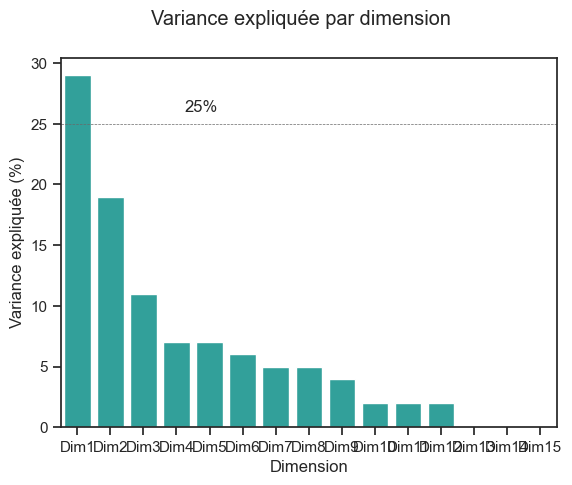

In [217]:
# Avant d'interpreter la PCA, on va d'abor choisir le nombre d'axes factoriels

# Scree plot pour choisir le nombre de composantes principales
g_comp = sns.barplot(x = "Dimension",
                y = "% variance expliquée",
                palette = ["lightseagreen"],
                data = comp)
g_comp.set(ylabel = "Variance expliquée (%)")
g_comp.figure.suptitle("Variance expliquée par dimension")
plt.axhline(y = 25, linewidth = .5, color = "dimgray", linestyle = "--") # 25 = 100 / 4 (nb dimension)
plt.text(3.25, 26, "25%")

 Ici on a 15 axes factoriels car on 15 variables

#### Autres aides à l'interpretation

#### Pour les variables

In [222]:
# Calcul du cosinus carré des variables
# (Ici, on Ne normalise pas les valeurs, ce qui signifie qu'on ne peut pas directement comparer les contributions entre axes.)

cos_squared = np.square(pca.components_)

# Création d'un dataframe pandas avec le cosinus carré des variables
df_cos_squared = pd.DataFrame(cos_squared, columns=['PC{}'.format(i+1) for i in range(x.shape[1])])
df_cos_squared.index = df_miss.columns[1:]

print(df_cos_squared)


                      PC1       PC2       PC3       PC4       PC5       PC6  \
Energ_Kcal       0.206126  0.004336  0.147326  0.042977  0.026473  0.019409   
Protein_(g)      0.006358  0.001295  0.109536  0.105154  0.129334  0.094299   
Lipid_Tot_(g)    0.010790  0.345235  0.002410  0.217305  0.033364  0.066420   
Carbohydrt_(g)   0.000298  0.033107  0.000802  0.012776  0.060937  0.098192   
Fiber_TD_(g)     0.006766  0.055486  0.008253  0.018757  0.000912  0.071693   
Calcium_(mg)     0.036521  0.090782  0.005825  0.060446  0.115581  0.004492   
Iron_(mg)        0.003800  0.192562  0.005529  0.000394  0.000964  0.333863   
Sodium_(mg)      0.007429  0.000595  0.010364  0.072228  0.026313  0.001582   
Water_(g)        0.002239  0.003078  0.001477  0.005394  0.212795  0.005292   
Magnesium_(mg)   0.000584  0.083650  0.000078  0.004900  0.380944  0.021431   
Phosphorus_(mg)  0.000585  0.002450  0.000141  0.004531  0.000766  0.008679   
Vit_C_(mg)       0.005120  0.115147  0.000932  0.000

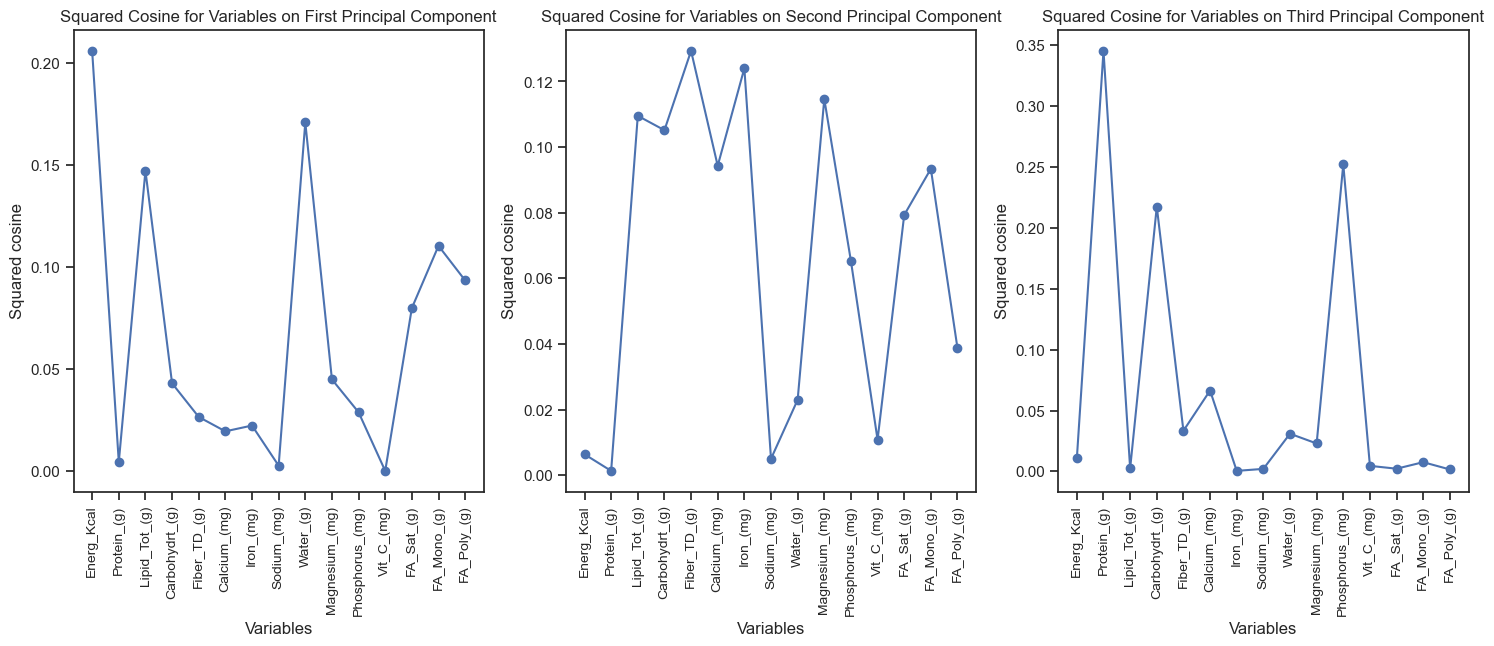

In [226]:
# Calculer les carrés des cosinus des variables sur les axes principaux
# Normalisation par la somme des cos² pour chaque axe, Permet de comparer les contributions relatives entre variables.

cos2 = pca.components_ ** 2
row_sums = cos2.sum(axis=1)
cos2 = cos2 / row_sums[:, np.newaxis]

# Afficher les graphiques des carrés des cosinus des variables sur les axes principaux pour le premier, le deuxième et le troisième axe principal
n_comp = pca.n_components_
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
axs[0].plot(range(1, len(vars_list)+1), cos2[0,:], '-o')
axs[0].set_xticks(range(1, len(vars_list)+1))
axs[0].set_xticklabels(vars_list, rotation=90, fontsize=10)
axs[0].set_xlabel("Variables")
axs[0].set_ylabel("Squared cosine")
axs[0].set_title("Squared Cosine for Variables on First Principal Component")
axs[1].plot(range(1, len(vars_list)+1), cos2[1,:], '-o')
axs[1].set_xticks(range(1, len(vars_list)+1))
axs[1].set_xticklabels(vars_list, rotation=90, fontsize=10)
axs[1].set_xlabel("Variables")
axs[1].set_ylabel("Squared cosine")
axs[1].set_title("Squared Cosine for Variables on Second Principal Component")
axs[2].plot(range(1, len(vars_list)+1), cos2[2,:], '-o')
axs[2].set_xticks(range(1, len(vars_list)+1))
axs[2].set_xticklabels(vars_list, rotation=90, fontsize=10)
axs[2].set_xlabel("Variables")
axs[2].set_ylabel("Squared cosine")
axs[2].set_title("Squared Cosine for Variables on Third Principal Component")
plt.show()

In [228]:
df.index

Index([ 1001,  1002,  1003,  1004,  1005,  1006,  1007,  1008,  1009,  1010,
       ...
       44258, 44259, 44260, 48052, 80200, 83110, 90240, 90480, 90560, 93600],
      dtype='int64', name='NDB_No', length=8790)

In [243]:
# Contribution à la formation de l'axe
# Obtenir les composantes principales
components = pca.components_
## pca.components_ : Récupère la matrice des coefficients des composantes principales.
## Chaque ligne correspond à une composante principale (axe).
## Chaque colonne correspond à une variable originale.
## components : Stocke cette matrice pour une utilisation ultérieure.


n_components = x.shape[1]
# x correspond aux variables explicatives après une ACP
# shape est un attribut des objets NumPy (et pandas) qui retourne un tuple contenant les dimensions du tableau.

# x.shape[1] : Récupère le nombre de colonnes (variables) dans le jeu de données x utilisé pour l'ACP.
feature_names=df.columns[1:]
# Calculer la contribution des variables à la formation des axes
loadings = pca.components_.T # pca.components_.T : Transpose la matrice des composantes principales.
## Avant la transposition : chaque ligne correspond à une composante principale, et chaque colonne à une variable originale.
## Après la transposition : chaque ligne correspond à une variable originale, et chaque colonne à une composante principale.
eigenvalues = pca.explained_variance_ # Récupère les valeurs propres (variances expliquées) de chaque composante principale.
variable_contributions = (loadings**2) * eigenvalues


# Créer un DataFrame pour faciliter l'affichage des résultats
column_names = [f'PC{i+1}_contrib' for i in range(n_components)]
variable_contrib_df = pd.DataFrame(variable_contributions, columns=column_names, index=feature_names)

print(variable_contrib_df)

                 PC1_contrib  PC2_contrib  PC3_contrib  PC4_contrib  \
Energ_Kcal          0.908005     0.017823     0.018428     0.000330   
Protein_(g)         0.019103     0.003629     0.589614     0.036659   
Lipid_Tot_(g)       0.648985     0.307069     0.004117     0.000888   
Carbohydrt_(g)      0.189316     0.294784     0.371126     0.014146   
Fiber_TD_(g)        0.116616     0.362570     0.056981     0.067474   
Calcium_(mg)        0.085498     0.264353     0.113436     0.108725   
Iron_(mg)           0.098032     0.347702     0.000761     0.019242   
Sodium_(mg)         0.011296     0.013952     0.003559     0.700905   
Water_(g)           0.753380     0.064343     0.052859     0.009468   
Magnesium_(mg)      0.197758     0.321460     0.039170     0.104781   
Phosphorus_(mg)     0.126750     0.182954     0.430501     0.015337   
Vit_C_(mg)          0.000022     0.030293     0.007807     0.015903   
FA_Sat_(g)          0.352057     0.222315     0.003798     0.003726   
FA_Mon

In [234]:
# Calculer la contribution des variables à la formation des axes (Normalisé)
loadings = pca.components_.T
eigenvalues = pca.explained_variance_
variable_contributions = (loadings**2) * eigenvalues

# Convertir les contributions en pourcentage
variable_contrib_percent = variable_contributions / eigenvalues * 100

# Créer un DataFrame pour faciliter l'affichage des résultats
column_names = [f'PC{i+1}_contrib' for i in range(n_components)]
variable_contrib_df = pd.DataFrame(variable_contrib_percent, columns=column_names, index=feature_names)

print(variable_contrib_df)

                 PC1_contrib  PC2_contrib  PC3_contrib  PC4_contrib  \
Energ_Kcal         20.612576     0.635759     1.079037     0.029820   
Protein_(g)         0.433645     0.129461    34.523508     3.310723   
Lipid_Tot_(g)      14.732564    10.953589     0.241045     0.080164   
Carbohydrt_(g)      4.297661    10.515362    21.730463     1.277575   
Fiber_TD_(g)        2.647285    12.933380     3.336370     6.093707   
Calcium_(mg)        1.940889     9.429859     6.641997     9.819177   
Iron_(mg)           2.225412    12.403027     0.044533     1.737821   
Sodium_(mg)         0.256430     0.497686     0.208401    63.300077   
Water_(g)          17.102424     2.295204     3.095067     0.855098   
Magnesium_(mg)      4.489299    11.466960     2.293526     9.462958   
Phosphorus_(mg)     2.877339     6.526246    25.206995     1.385096   
Vit_C_(mg)          0.000489     1.080584     0.457135     1.436201   
FA_Sat_(g)          7.992036     7.930300     0.222378     0.336477   
FA_Mon

#### Pour les individus

In [239]:
# Calculer la contribution des individus à la formation des axes
eigenvalues = pca.explained_variance_
contributions = (X_pca**2) / (X_pca.shape[0] * eigenvalues)

# Convertir les contributions en pourcentage
contrib_percent = contributions * 100

# Créer un DataFrame pour faciliter l'affichage des résultats
column_names = [f'PC{i+1}_contrib' for i in range(n_components)]
contrib_df = pd.DataFrame(contrib_percent, columns=column_names)

print(contrib_df)


      PC1_contrib  PC2_contrib  PC3_contrib  PC4_contrib  PC5_contrib  \
0        0.090542     0.121664     0.000645     0.007634     0.008316   
1        0.079689     0.105436     0.001357     0.006400     0.006702   
2        0.157242     0.188321     0.001150     0.001150     0.011186   
3        0.010511     0.002060     0.033759     0.028549     0.004046   
4        0.013599     0.000967     0.047268     0.019995     0.006338   
...           ...          ...          ...          ...          ...   
8785     0.005950     0.002112     0.012490     0.111850     0.000115   
8786     0.003582     0.000577     0.016787     0.000795     0.000900   
8787     0.000132     0.002283     0.032125     0.001561     0.003472   
8788     0.001102     0.009066     0.018003     0.023973     0.000053   
8789     0.006734     0.000010     0.008866     0.000279     0.000116   

      PC6_contrib  PC7_contrib  PC8_contrib  PC9_contrib  PC10_contrib  \
0        0.071918     0.060913     0.105065     0

#### Representation graphique et interpretation

In [248]:
#fonction qui permet de tracer le graphes de corrélations selon les plans choisis

def correlation_graph(pca, 
                      x_y, 
                      features) : 
    """Affiche le graphe des correlations

    Positional arguments : 
    -----------------------------------
    pca : sklearn.decomposition.PCA : notre objet PCA qui a été fit
    x_y : list ou tuple : le couple x,y des plans à afficher, exemple [0,1] pour F1, F2
    features : list ou tuple : la liste des features (ie des dimensions) à représenter
    """

    # Extrait x et y 
    x,y=x_y # x_y est une structure contenant deux éléments, souvent un tuple ou une liste.

    # x, y = x_y : Python assigne chaque élément du tuple/liste à une variable distincte.
    # Si x_y = (première_valeur, deuxième_valeur), alors : x reçoit première_valeur, y reçoit deuxième_valeur

    # Taille de l'image (en inches)
    fig, ax = plt.subplots(figsize=(10, 9))

    # Pour chaque composante : 
    for i in range(0, pca.components_.shape[1]):

        # Les flèches
        ax.arrow(0,0, 
                pca.components_[x, i],  
                pca.components_[y, i],  
                head_width=0.07,
                head_length=0.07, 
                width=0.02, )

        # Les labels
        plt.text(pca.components_[x, i] + 0.05,
                pca.components_[y, i] + 0.05,
                features[i], fontsize=12, weight='bold',color='b')
        
    # Affichage des lignes horizontales et verticales
    plt.plot([-1, 1], [0, 0], color='grey', ls='--')
    plt.plot([0, 0], [-1, 1], color='grey', ls='--')

    # Nom des axes, avec le pourcentage d'inertie expliqué
    plt.xlabel('F{} ({}%)'.format(x+1, round(100*pca.explained_variance_ratio_[x],1)))
    plt.ylabel('F{} ({}%)'.format(y+1, round(100*pca.explained_variance_ratio_[y],1)))

    # Titre du graphe
    plt.title("Cercle des corrélations (F{} et F{})".format(x+1, y+1))

    # Le cercle 
    an = np.linspace(0, 2 * np.pi, 100)
    plt.plot(np.cos(an), np.sin(an))  # Add a unit circle for scale

    # Axes et display
    plt.axis('equal')
    plt.savefig('CorrGraph_{}.jpg'.format(x_y), bbox_inches='tight')
    plt.show(block=False)

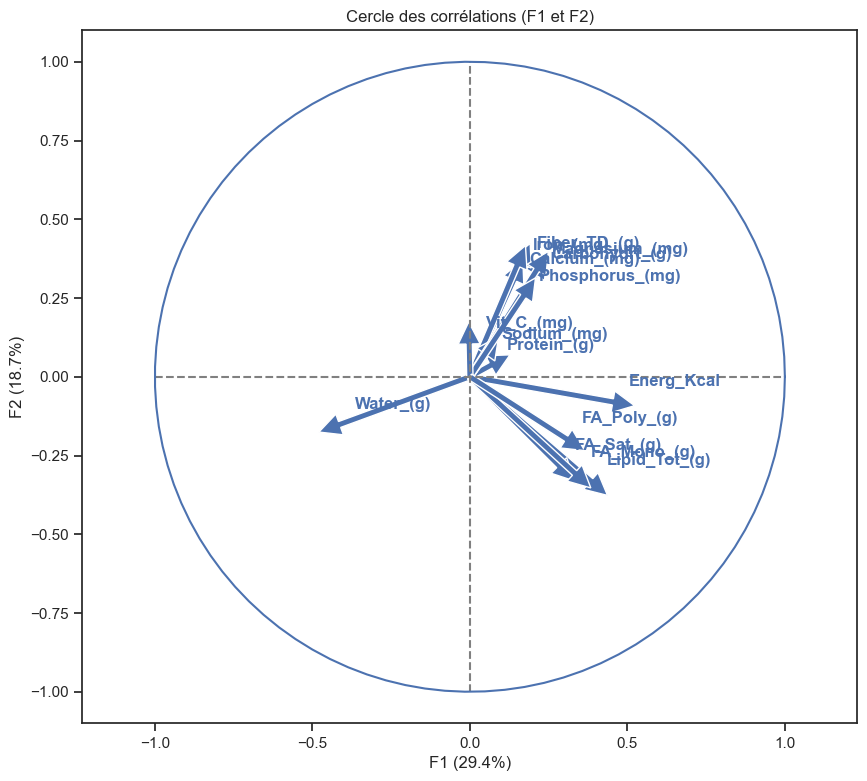

In [250]:
#pour F1 et F2 (Pour le premier er deuxieme axe factoriel)
x_y = (0,1)
x_y
correlation_graph(pca, x_y, vars_list)

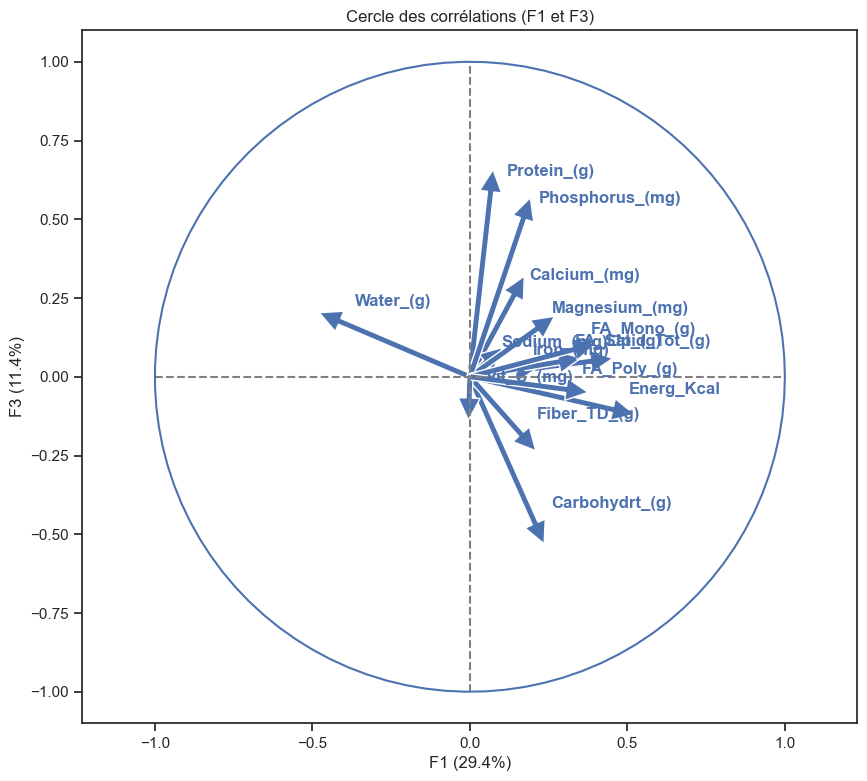

In [252]:
#pour F2 et F3 (pour le premier et le troisieme axe factoriel)
x_y = (0,2)
x_y
correlation_graph(pca, x_y, vars_list)

In [ ]:
#pour F2 et F3 (Pour le deuxieme et troisieme axe)
x_y = (1,2)
x_y
correlation_graph(pca, x_y, vars_list)